# Đồ án: So sánh PhoBERT Fine-tuning và LSTM đa nhiệm trên UIT-VSFC

## Phân tích cảm xúc và chủ đề phản hồi sinh viên tiếng Việt

Notebook này xây dựng một pipeline hoàn chỉnh:

1. Cài đặt môi trường và kiểm tra GPU.
2. Tải, chuẩn hóa và khám phá dataset UIT-VSFC.
3. Tiền xử lý văn bản và tách từ tiếng Việt.
4. Xây dựng baseline TF-IDF + Logistic Regression.
5. Fine-tune **PhoBERT-base-v2 đa nhiệm**:
   - Cảm xúc: `negative`, `neutral`, `positive`.
   - Chủ đề: `lecturer`, `training_program`, `facility`, `others`.
6. Huấn luyện **LSTM đa nhiệm** trên đúng các train/validation/test split của PhoBERT.
7. Đánh giá hai mô hình bằng Accuracy, Macro-F1, Weighted-F1, classification report và confusion matrix.
8. So sánh trực tiếp **PhoBERT vs LSTM** bằng bảng tổng hợp và biểu đồ Macro-F1.
9. Phân tích lỗi và dự đoán dữ liệu mới bằng PhoBERT.
10. Demo Gradio và lưu các artifact/kết quả thực nghiệm.

> **Khuyến nghị:** Chọn `Runtime → Change runtime type → T4 GPU` trước khi chạy PhoBERT.  
> LSTM có thể chạy trên CPU, nhưng dùng GPU sẽ nhanh hơn.

**Nguồn tham khảo**

- Dataset gốc: https://huggingface.co/datasets/uitnlp/vietnamese_students_feedback
- Bản dữ liệu dạng bảng dùng trong notebook: https://huggingface.co/datasets/tridm/UIT-VSFC
- PhoBERT-base-v2: https://huggingface.co/vinai/phobert-base-v2
- Bài báo UIT-VSFC: DOI `10.1109/KSE.2018.8573337`
- Bài báo PhoBERT: https://aclanthology.org/2020.findings-emnlp.92/


## 1. Cài đặt thư viện

Notebook ghim các **major version** để giảm nguy cơ lỗi API nhưng vẫn cho phép pip chọn bản vá tương thích mới nhất.

Sau khi cài đặt, Colab có thể yêu cầu khởi động lại runtime nếu môi trường đang chứa phiên bản thư viện xung đột.

In [ ]:
%%capture
!pip install -q \
    "transformers>=4.44,<5" \
    "datasets>=3.0,<5" \
    "accelerate>=0.33" \
    "scikit-learn>=1.4" \
    "pandas>=2.0" \
    "matplotlib>=3.7" \
    "seaborn>=0.13" \
    "py_vncorenlp>=0.1.4" \
    "gradio>=5,<7" \
    "tqdm>=4.66"

## 2. Import, seed và cấu hình thí nghiệm

### Chế độ chạy

- `FAST_MODE = True`: chạy thử pipeline nhanh với một phần dữ liệu và 1 epoch.
- `FAST_MODE = False`: chạy đồ án chính thức với toàn bộ dữ liệu.
- `USE_VNCORENLP = True`: tách từ bằng RDRSegmenter, phù hợp khuyến nghị của PhoBERT.


In [ ]:
import os
import gc
import json
import math
import random
import shutil
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import FeatureUnion
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoModel,
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# -------------------- CẤU HÌNH CHÍNH --------------------
SEED = 42
FAST_MODE = False
USE_VNCORENLP = True
RUN_BASELINE = True
RUN_LSTM = True

DATASET_NAME = "tridm/UIT-VSFC"
MODEL_NAME = "vinai/phobert-base-v2"

MAX_LENGTH = 128
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
GRADIENT_ACCUMULATION_STEPS = 1
EPOCHS = 7
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
MAX_GRAD_NORM = 1.0
PATIENCE = 2
DROPOUT = 0.20

# -------------------- CẤU HÌNH LSTM --------------------
# LSTM dùng cùng train/validation/test split để so sánh công bằng với PhoBERT.
LSTM_MAX_VOCAB_SIZE = 30000
LSTM_MIN_FREQ = 2
LSTM_MAX_LENGTH = 128
LSTM_EMBED_DIM = 128
LSTM_HIDDEN_SIZE = 128
LSTM_NUM_LAYERS = 1
LSTM_BIDIRECTIONAL = False
LSTM_DROPOUT = 0.30
LSTM_BATCH_SIZE = 64
LSTM_EVAL_BATCH_SIZE = 128
LSTM_EPOCHS = 20
LSTM_LEARNING_RATE = 1e-3
LSTM_WEIGHT_DECAY = 1e-4
LSTM_PATIENCE = 3
LSTM_MAX_GRAD_NORM = 1.0

# Trọng số loss đa nhiệm
LAMBDA_SENTIMENT = 0.5
LAMBDA_TOPIC = 0.5

# Dùng class weight để giảm ảnh hưởng mất cân bằng lớp
USE_CLASS_WEIGHTS = True

# None = fine-tune toàn bộ encoder.
# Ví dụ: 4 = chỉ mở 4 Transformer blocks cuối và classification heads.
UNFREEZE_LAST_N_LAYERS = None

OUTPUT_DIR = Path("/content/uit_vsfc_phobert_project")
CACHE_DIR = OUTPUT_DIR / "cache"
BEST_MODEL_PATH = OUTPUT_DIR / "best_multitask_model.pt"
BEST_LSTM_MODEL_PATH = OUTPUT_DIR / "best_lstm_multitask_model.pt"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

if FAST_MODE:
    EPOCHS = 1
    TRAIN_BATCH_SIZE = 16
    EVAL_BATCH_SIZE = 32
    LSTM_EPOCHS = 1
    LSTM_BATCH_SIZE = 64
    LSTM_EVAL_BATCH_SIZE = 128

def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

print("PyTorch:", torch.__version__)
print("Thiết bị:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("Cảnh báo: Chưa bật GPU. Hãy chọn Runtime → Change runtime type → GPU.")

PyTorch: 2.11.0+cu128
Thiết bị: cuda
GPU: Tesla T4
VRAM: 14.6 GB


## 3. Tải và chuẩn hóa UIT-VSFC

Dataset gốc có ba split:

| Split | Số mẫu dự kiến |
|---|---:|
| Train | 11.426 |
| Validation | 1.583 |
| Test | 3.166 |

Bản `tridm/UIT-VSFC` chứa sẵn cả nhãn dạng chữ và dạng số, thuận tiện với các phiên bản `datasets` hiện đại. Hàm bên dưới vẫn kiểm tra tên cột để notebook không phụ thuộc tuyệt đối vào cách viết hoa.

In [ ]:
raw_dataset = load_dataset(DATASET_NAME)
raw_dataset

train.json: 0.00B [00:00, ?B/s]

valid.json: 0.00B [00:00, ?B/s]

test.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1583 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3166 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['Sentence', 'Topic', 'Sentiment', 'Encoded_topic', 'Encoded_sentiment'],
        num_rows: 11426
    })
    validation: Dataset({
        features: ['Sentence', 'Topic', 'Sentiment', 'Encoded_topic', 'Encoded_sentiment'],
        num_rows: 1583
    })
    test: Dataset({
        features: ['Sentence', 'Topic', 'Sentiment', 'Encoded_topic', 'Encoded_sentiment'],
        num_rows: 3166
    })
})

In [ ]:
SENTIMENT_NAMES = ["negative", "neutral", "positive"]
TOPIC_NAMES = ["lecturer", "training_program", "facility", "others"]

SENTIMENT_TO_ID = {name: idx for idx, name in enumerate(SENTIMENT_NAMES)}
TOPIC_ALIASES_TO_ID = {
    "lecturer": 0,
    "teacher": 0,
    "training_program": 1,
    "training program": 1,
    "program": 1,
    "facility": 2,
    "facilities": 2,
    "others": 3,
    "other": 3,
}
ID_TO_SENTIMENT = {idx: name for idx, name in enumerate(SENTIMENT_NAMES)}
ID_TO_TOPIC = {idx: name for idx, name in enumerate(TOPIC_NAMES)}

def _find_column(df: pd.DataFrame, candidates):
    lookup = {str(c).strip().lower(): c for c in df.columns}
    for candidate in candidates:
        if candidate.lower() in lookup:
            return lookup[candidate.lower()]
    return None

def standardize_split(hf_split) -> pd.DataFrame:
    df = hf_split.to_pandas().copy()

    text_col = _find_column(df, ["sentence", "text", "feedback"])
    sentiment_id_col = _find_column(
        df, ["encoded_sentiment", "sentiment_id", "label_sentiment"]
    )
    topic_id_col = _find_column(
        df, ["encoded_topic", "topic_id", "label_topic"]
    )
    sentiment_text_col = _find_column(df, ["sentiment"])
    topic_text_col = _find_column(df, ["topic"])

    if text_col is None:
        raise ValueError(f"Không tìm thấy cột văn bản. Các cột hiện có: {list(df.columns)}")

    out = pd.DataFrame({"sentence": df[text_col].astype(str)})

    if sentiment_id_col is not None:
        out["sentiment"] = pd.to_numeric(df[sentiment_id_col], errors="raise").astype(int)
    elif sentiment_text_col is not None:
        normalized = df[sentiment_text_col].astype(str).str.strip().str.lower()
        out["sentiment"] = normalized.map(SENTIMENT_TO_ID)
    else:
        raise ValueError("Không tìm thấy nhãn sentiment.")

    if topic_id_col is not None:
        out["topic"] = pd.to_numeric(df[topic_id_col], errors="raise").astype(int)
    elif topic_text_col is not None:
        normalized = df[topic_text_col].astype(str).str.strip().str.lower()
        out["topic"] = normalized.map(TOPIC_ALIASES_TO_ID)
    else:
        raise ValueError("Không tìm thấy nhãn topic.")

    if out[["sentiment", "topic"]].isna().any().any():
        bad_rows = out[out[["sentiment", "topic"]].isna().any(axis=1)].head()
        raise ValueError(f"Có nhãn không ánh xạ được:\n{bad_rows}")

    out["sentiment"] = out["sentiment"].astype(int)
    out["topic"] = out["topic"].astype(int)
    out["sentence"] = (
        out["sentence"]
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
    )
    return out

train_df = standardize_split(raw_dataset["train"])
val_df = standardize_split(raw_dataset["validation"])
test_df = standardize_split(raw_dataset["test"])

if FAST_MODE:
    train_df = train_df.sample(min(2500, len(train_df)), random_state=SEED).reset_index(drop=True)
    val_df = val_df.sample(min(600, len(val_df)), random_state=SEED).reset_index(drop=True)
    test_df = test_df.sample(min(800, len(test_df)), random_state=SEED).reset_index(drop=True)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)
display(train_df.head())

Train: (11426, 3)
Validation: (1583, 3)
Test: (3166, 3)


,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0


## 4. Kiểm tra chất lượng và khám phá dữ liệu

Không xóa dấu tiếng Việt, stopword hoặc dấu phủ định vì các thông tin này rất quan trọng đối với sentiment.  
Các bước kiểm tra gồm:

- Giá trị thiếu.
- Văn bản rỗng.
- Trùng lặp.
- Phân bố nhãn.
- Độ dài câu.
- Mối quan hệ giữa nhãn cảm xúc và chủ đề.

In [ ]:
def data_quality_report(name: str, df: pd.DataFrame):
    print(f"===== {name.upper()} =====")
    print("Số dòng:", len(df))
    print("Giá trị thiếu:")
    print(df.isna().sum())
    print("Câu rỗng:", (df["sentence"].str.len() == 0).sum())
    print("Câu trùng trong split:", df["sentence"].duplicated().sum())
    print("Sentiment IDs:", sorted(df["sentiment"].unique().tolist()))
    print("Topic IDs:", sorted(df["topic"].unique().tolist()))
    print()

for split_name, frame in [("train", train_df), ("validation", val_df), ("test", test_df)]:
    data_quality_report(split_name, frame)

===== TRAIN =====
Số dòng: 11426
Giá trị thiếu:
sentence     0
sentiment    0
topic        0
dtype: int64
Câu rỗng: 0
Câu trùng trong split: 1
Sentiment IDs: [0, 1, 2]
Topic IDs: [0, 1, 2, 3]

===== VALIDATION =====
Số dòng: 1583
Giá trị thiếu:
sentence     0
sentiment    0
topic        0
dtype: int64
Câu rỗng: 0
Câu trùng trong split: 0
Sentiment IDs: [0, 1, 2]
Topic IDs: [0, 1, 2, 3]

===== TEST =====
Số dòng: 3166
Giá trị thiếu:
sentence     0
sentiment    0
topic        0
dtype: int64
Câu rỗng: 0
Câu trùng trong split: 0
Sentiment IDs: [0, 1, 2]
Topic IDs: [0, 1, 2, 3]



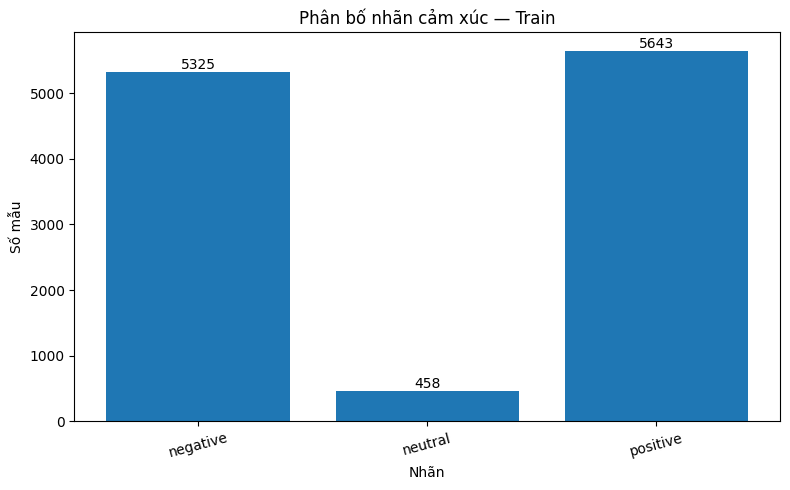

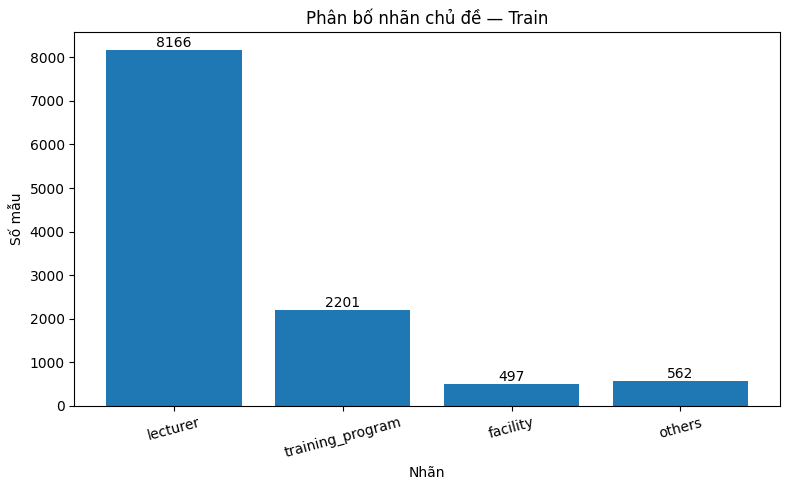

In [ ]:
def label_distribution_plot(df, label_col, label_names, title):
    counts = (
        df[label_col]
        .value_counts()
        .reindex(range(len(label_names)), fill_value=0)
    )
    labels = [label_names[i] for i in counts.index]

    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, counts.values)
    plt.title(title)
    plt.xlabel("Nhãn")
    plt.ylabel("Số mẫu")
    plt.xticks(rotation=15)
    for bar, value in zip(bars, counts.values):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            str(value),
            ha="center",
            va="bottom",
        )
    plt.tight_layout()
    plt.show()

label_distribution_plot(
    train_df, "sentiment", SENTIMENT_NAMES, "Phân bố nhãn cảm xúc — Train"
)
label_distribution_plot(
    train_df, "topic", TOPIC_NAMES, "Phân bố nhãn chủ đề — Train"
)

,word_count,char_count
count,11426.000000,11426.000000
mean,14.308769,59.084457
std,10.089727,43.084680
min,2.000000,4.000000
50%,11.000000,47.000000
90%,26.000000,110.000000
95%,33.000000,141.000000
99%,52.000000,218.750000
max,159.000000,660.000000


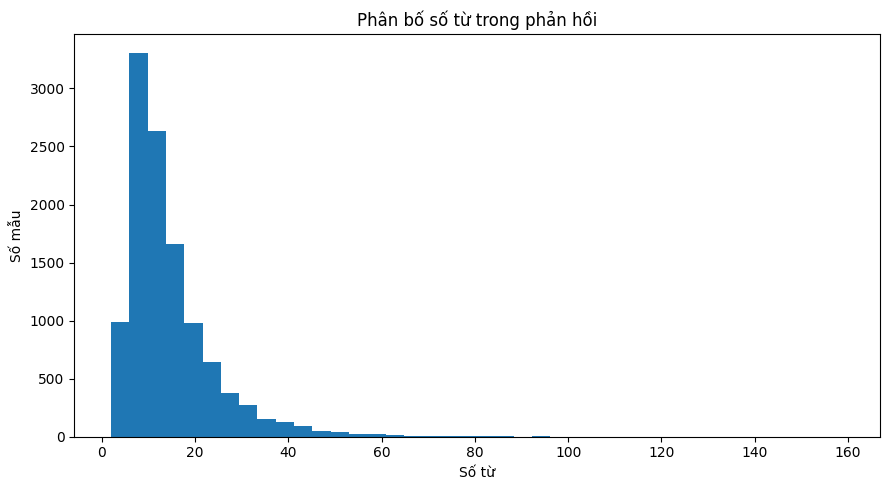

In [ ]:
eda_df = train_df.copy()
eda_df["word_count"] = eda_df["sentence"].str.split().str.len()
eda_df["char_count"] = eda_df["sentence"].str.len()

display(eda_df[["word_count", "char_count"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure(figsize=(9, 5))
plt.hist(eda_df["word_count"], bins=40)
plt.title("Phân bố số từ trong phản hồi")
plt.xlabel("Số từ")
plt.ylabel("Số mẫu")
plt.tight_layout()
plt.show()

sentiment,negative,neutral,positive
topic,,,
facility,474,10,13
lecturer,2909,186,5071
others,226,161,175
training_program,1716,101,384


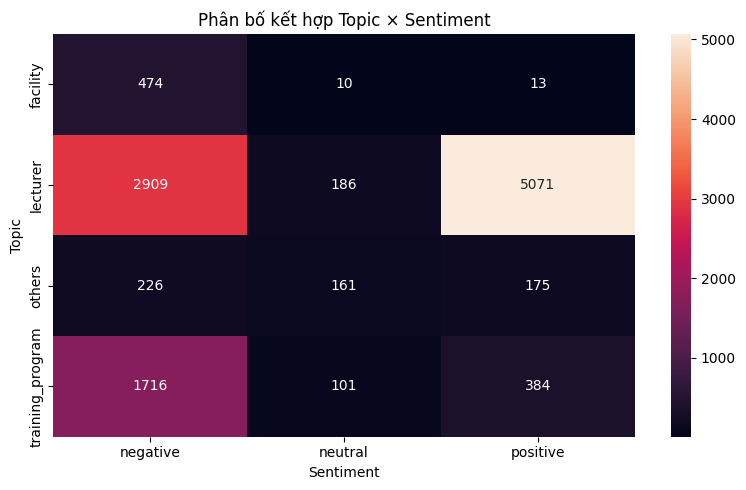

In [ ]:
cross_tab = pd.crosstab(
    train_df["topic"].map(ID_TO_TOPIC),
    train_df["sentiment"].map(ID_TO_SENTIMENT),
)
display(cross_tab)

plt.figure(figsize=(8, 5))
sns.heatmap(cross_tab, annot=True, fmt="d")
plt.title("Phân bố kết hợp Topic × Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

## 5. Tiền xử lý và tách từ tiếng Việt

PhoBERT được pre-train trên văn bản đã tách từ, trong đó các tiếng thuộc cùng một từ được nối bằng dấu gạch dưới, ví dụ:

```text
sinh viên công nghệ thông tin
→ sinh_viên công_nghệ thông_tin
```

Notebook sử dụng `py_vncorenlp` và lưu cache để không phải tách từ lại khi chạy lại cell.

> Nếu môi trường gặp lỗi Java hoặc chỉ cần kiểm tra nhanh, đặt `USE_VNCORENLP = False`. Mô hình vẫn chạy nhưng có thể không khai thác PhoBERT tối ưu.

In [ ]:
import re

def normalize_text(text: str) -> str:
    text = str(text)
    text = text.replace("\u200b", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

# JVM của VnCoreNLP chỉ khởi động được MỘT lần cho mỗi runtime, vì vậy giữ lại
# segmenter đã tạo trước đó để có thể chạy lại cell (hoặc Run all) nhiều lần.
segmenter = globals().get("segmenter", None)

def word_segment_text(text: str) -> str:
    text = normalize_text(text)
    if not USE_VNCORENLP or segmenter is None:
        return text

    sentences = segmenter.word_segment(text)
    return " ".join(sentences).strip()

if USE_VNCORENLP and segmenter is None:
    import py_vncorenlp

    VNCORE_DIR = Path("/content/vncorenlp")
    VNCORE_DIR.mkdir(parents=True, exist_ok=True)

    # Kiểm tra file mô hình; nếu chưa có thì tải một lần.
    model_files = list(VNCORE_DIR.rglob("*"))
    if len(model_files) < 3:
        print("Đang tải VnCoreNLP...")
        py_vncorenlp.download_model(save_dir=str(VNCORE_DIR))

    try:
        segmenter = py_vncorenlp.VnCoreNLP(
            annotators=["wseg"],
            save_dir=str(VNCORE_DIR),
        )
    except ValueError as exc:
        if "VM is already running" not in str(exc):
            raise
        raise RuntimeError(
            "JVM đã khởi động trước đó nhưng segmenter không còn trong bộ nhớ. "
            "Hãy chọn Runtime → Restart session rồi chạy lại notebook."
        ) from exc

demo_text = word_segment_text(
    "Giảng viên rất nhiệt tình và phòng máy cần được nâng cấp."
)
print(demo_text)

# Kiểm tra nhanh để tránh trường hợp segmenter lỗi mà vẫn chạy tiếp với văn bản thô.
if USE_VNCORENLP and "_" not in demo_text:
    raise RuntimeError(
        "VnCoreNLP không tách từ được. Hãy Restart session hoặc đặt USE_VNCORENLP = False."
    )

Đang tải VnCoreNLP...
Giảng_viên rất nhiệt_tình và phòng máy cần được nâng_cấp .


In [ ]:
def _looks_segmented(texts) -> bool:
    """Kiểm tra thô xem văn bản đã được tách từ (có dấu gạch dưới) hay chưa."""
    sample = pd.Series(texts).astype(str).head(300)
    if len(sample) == 0:
        return False
    return float(sample.str.contains("_").mean()) > 0.05

def segment_dataframe(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    cache_file = CACHE_DIR / f"{split_name}_segmented.csv"

    if cache_file.exists():
        cached = pd.read_csv(cache_file)
        required = {"sentence", "segmented_text", "sentiment", "topic"}
        cache_ok = required.issubset(cached.columns) and len(cached) == len(df)

        # Cache chỉ hợp lệ nếu trạng thái tách từ trùng với cấu hình hiện tại.
        if cache_ok and USE_VNCORENLP and not _looks_segmented(cached["segmented_text"]):
            print(f"Cache {cache_file.name} chưa được tách từ — sẽ tạo lại.")
            cache_ok = False

        if cache_ok:
            print(f"Đã tải cache: {cache_file}")
            return cached

    result = df.copy()
    tqdm.pandas(desc=f"Tách từ {split_name}")
    result["segmented_text"] = result["sentence"].progress_apply(word_segment_text)
    result.to_csv(cache_file, index=False)
    print(f"Đã lưu cache: {cache_file}")
    return result

train_df = segment_dataframe(train_df, "train")
val_df = segment_dataframe(val_df, "validation")
test_df = segment_dataframe(test_df, "test")

display(train_df[["sentence", "segmented_text", "sentiment", "topic"]].head())

Tách từ train:   0%|          | 0/11426 [00:00<?, ?it/s]

Đã lưu cache: /content/uit_vsfc_phobert_project/cache/train_segmented.csv


Tách từ validation:   0%|          | 0/1583 [00:00<?, ?it/s]

Đã lưu cache: /content/uit_vsfc_phobert_project/cache/validation_segmented.csv


Tách từ test:   0%|          | 0/3166 [00:00<?, ?it/s]

Đã lưu cache: /content/uit_vsfc_phobert_project/cache/test_segmented.csv


,sentence,segmented_text,sentiment,topic
0,slide giáo trình đầy đủ .,slide giáo_trình đầy_đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .","nhiệt_tình giảng_dạy , gần_gũi với sinh_viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,đi học đầy_đủ full điểm chuyên_cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...","thầy giảng bài hay , có nhiều bài_tập ví_dụ ng...",2,0


## 6. Baseline: TF-IDF + Logistic Regression

Baseline giúp trả lời câu hỏi nghiên cứu:

> Fine-tuning Transformer có thực sự tốt hơn phương pháp machine learning truyền thống không?

Mô hình kết hợp:

- Word n-gram `(1, 2)`.
- Character n-gram `(3, 5)`.
- Logistic Regression có `class_weight="balanced"`.

In [ ]:
def metric_dict(y_true, y_pred):
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }

def print_metrics(metrics, prefix=""):
    title = f"{prefix}: " if prefix else ""
    print(
        f"{title}Accuracy={metrics['accuracy']:.4f} | "
        f"Macro-F1={metrics['f1_macro']:.4f} | "
        f"Weighted-F1={metrics['f1_weighted']:.4f}"
    )

baseline_results = {}
baseline_models = {}

if RUN_BASELINE:
    tfidf_features = FeatureUnion([
        (
            "word",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_df=0.98,
                max_features=50000,
                sublinear_tf=True,
            ),
        ),
        (
            "char",
            TfidfVectorizer(
                analyzer="char_wb",
                ngram_range=(3, 5),
                min_df=2,
                max_features=50000,
                sublinear_tf=True,
            ),
        ),
    ])

    print("Đang fit TF-IDF...")
    X_train_tfidf = tfidf_features.fit_transform(train_df["sentence"])
    X_val_tfidf = tfidf_features.transform(val_df["sentence"])
    X_test_tfidf = tfidf_features.transform(test_df["sentence"])

    for task, label_names in [
        ("sentiment", SENTIMENT_NAMES),
        ("topic", TOPIC_NAMES),
    ]:
        print(f"\n===== BASELINE: {task.upper()} =====")
        clf = LogisticRegression(
            max_iter=1500,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
        )
        clf.fit(X_train_tfidf, train_df[task])

        val_pred = clf.predict(X_val_tfidf)
        test_pred = clf.predict(X_test_tfidf)

        baseline_results[f"{task}_val"] = metric_dict(val_df[task], val_pred)
        baseline_results[f"{task}_test"] = metric_dict(test_df[task], test_pred)
        baseline_models[task] = clf

        print_metrics(baseline_results[f"{task}_val"], "Validation")
        print_metrics(baseline_results[f"{task}_test"], "Test")
        print(
            classification_report(
                test_df[task],
                test_pred,
                labels=list(range(len(label_names))),
                target_names=label_names,
                digits=4,
                zero_division=0,
            )
        )
else:
    print("RUN_BASELINE=False — bỏ qua baseline.")

Đang fit TF-IDF...

===== BASELINE: SENTIMENT =====
Validation: Accuracy=0.8876 | Macro-F1=0.7608 | Weighted-F1=0.8956
Test: Accuracy=0.8740 | Macro-F1=0.7428 | Weighted-F1=0.8807
              precision    recall  f1-score   support

    negative     0.8881    0.9070    0.8975      1409
     neutral     0.3466    0.5210    0.4163       167
    positive     0.9499    0.8818    0.9145      1590

    accuracy                         0.8740      3166
   macro avg     0.7282    0.7699    0.7428      3166
weighted avg     0.8906    0.8740    0.8807      3166


===== BASELINE: TOPIC =====
Validation: Accuracy=0.8250 | Macro-F1=0.7307 | Weighted-F1=0.8369
Test: Accuracy=0.8102 | Macro-F1=0.7243 | Weighted-F1=0.8259
                  precision    recall  f1-score   support

        lecturer     0.9598    0.8227    0.8860      2290
training_program     0.5923    0.7850    0.6752       572
        facility     0.8816    0.9241    0.9024       145
          others     0.3345    0.6164    0.4336  

## 7. Tokenizer và PyTorch Dataset

`MAX_LENGTH=128` phù hợp vì phản hồi trong UIT-VSFC thường ngắn. Có thể tăng lên 192 hoặc 256 nếu phân tích cho thấy nhiều câu bị cắt.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

class UITVSFCMultiTaskDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=128):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        encoded = self.tokenizer(
            row["segmented_text"],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )

        item = {key: value.squeeze(0) for key, value in encoded.items()}
        item["sentiment_labels"] = torch.tensor(
            int(row["sentiment"]), dtype=torch.long
        )
        item["topic_labels"] = torch.tensor(
            int(row["topic"]), dtype=torch.long
        )
        item["row_id"] = torch.tensor(idx, dtype=torch.long)
        return item

train_dataset = UITVSFCMultiTaskDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset = UITVSFCMultiTaskDataset(val_df, tokenizer, MAX_LENGTH)
test_dataset = UITVSFCMultiTaskDataset(test_df, tokenizer, MAX_LENGTH)

train_loader = DataLoader(
    train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=USE_AMP,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=USE_AMP,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=USE_AMP,
)

sample_batch = next(iter(train_loader))
print({key: tuple(value.shape) for key, value in sample_batch.items()})

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': (16, 128), 'token_type_ids': (16, 128), 'attention_mask': (16, 128), 'sentiment_labels': (16,), 'topic_labels': (16,), 'row_id': (16,)}


In [ ]:
# Kiểm tra tỷ lệ token bị cắt ở MAX_LENGTH hiện tại.
# Chỉ lấy mẫu để cell chạy nhanh.
length_sample = train_df["segmented_text"].sample(
    min(3000, len(train_df)), random_state=SEED
).tolist()

token_lengths = [
    len(tokenizer.encode(text, add_special_tokens=True))
    for text in tqdm(length_sample, desc="Đếm token")
]

truncation_rate = np.mean(np.array(token_lengths) > MAX_LENGTH)
print(f"Tỷ lệ mẫu có thể bị cắt tại MAX_LENGTH={MAX_LENGTH}: {truncation_rate:.2%}")
print(pd.Series(token_lengths).describe(percentiles=[0.9, 0.95, 0.99]))

Đếm token:   0%|          | 0/3000 [00:00<?, ?it/s]

Tỷ lệ mẫu có thể bị cắt tại MAX_LENGTH=128: 0.00%
count    3000.000000
mean       13.501667
std         8.360061
min         4.000000
50%        11.000000
90%        24.000000
95%        30.000000
99%        45.000000
max        84.000000
dtype: float64


## 8. Class weights

Macro-F1 có thể giảm mạnh nếu mô hình bỏ qua lớp hiếm như `neutral` hoặc `facility`.  
Class weight được tính **chỉ từ train split** để tránh rò rỉ dữ liệu.

In [ ]:
def make_class_weights(labels, num_classes):
    classes = np.arange(num_classes)
    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=np.asarray(labels),
    )
    return torch.tensor(weights, dtype=torch.float32, device=DEVICE)

if USE_CLASS_WEIGHTS:
    sentiment_class_weights = make_class_weights(
        train_df["sentiment"], len(SENTIMENT_NAMES)
    )
    topic_class_weights = make_class_weights(
        train_df["topic"], len(TOPIC_NAMES)
    )
else:
    sentiment_class_weights = torch.ones(len(SENTIMENT_NAMES), device=DEVICE)
    topic_class_weights = torch.ones(len(TOPIC_NAMES), device=DEVICE)

print("Sentiment class weights:", sentiment_class_weights)
print("Topic class weights:", topic_class_weights)

Sentiment class weights: tensor([0.7152, 8.3159, 0.6749], device='cuda:0')
Topic class weights: tensor([0.3498, 1.2978, 5.7475, 5.0827], device='cuda:0')


## 9. Mô hình PhoBERT đa nhiệm

Kiến trúc:

```text
                           ┌── Sentiment head → 3 lớp
Input → PhoBERT encoder ───┤
                           └── Topic head     → 4 lớp
```

Loss:

\[
L = \lambda_s L_{	ext{sentiment}} + \lambda_t L_{	ext{topic}}
\]

Mặc định:

\[
\lambda_s = \lambda_t = 0.5
\]

In [ ]:
class PhoBERTMultiTask(nn.Module):
    def __init__(
        self,
        model_name,
        num_sentiment_labels=3,
        num_topic_labels=4,
        dropout=0.2,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        hidden_size = self.encoder.config.hidden_size

        self.dropout = nn.Dropout(dropout)
        self.sentiment_classifier = nn.Linear(hidden_size, num_sentiment_labels)
        self.topic_classifier = nn.Linear(hidden_size, num_topic_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        kwargs = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
        }
        # PhoBERT thường không dùng token_type_ids, nhưng giữ tương thích tổng quát.
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids

        outputs = self.encoder(**kwargs)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        cls_embedding = self.dropout(cls_embedding)

        sentiment_logits = self.sentiment_classifier(cls_embedding)
        topic_logits = self.topic_classifier(cls_embedding)
        return sentiment_logits, topic_logits

def configure_trainable_layers(model, unfreeze_last_n=None):
    # Mặc định fine-tune toàn bộ encoder.
    for param in model.encoder.parameters():
        param.requires_grad = True

    if unfreeze_last_n is None:
        return

    # Freeze toàn bộ encoder trước.
    for param in model.encoder.parameters():
        param.requires_grad = False

    # Embedding vẫn đóng băng; chỉ mở N layer cuối.
    encoder_layers = model.encoder.encoder.layer
    n = min(unfreeze_last_n, len(encoder_layers))
    for layer in encoder_layers[-n:]:
        for param in layer.parameters():
            param.requires_grad = True

    # Luôn huấn luyện hai classification heads.
    for param in model.sentiment_classifier.parameters():
        param.requires_grad = True
    for param in model.topic_classifier.parameters():
        param.requires_grad = True

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

model = PhoBERTMultiTask(
    MODEL_NAME,
    num_sentiment_labels=len(SENTIMENT_NAMES),
    num_topic_labels=len(TOPIC_NAMES),
    dropout=DROPOUT,
)
configure_trainable_layers(model, UNFREEZE_LAST_N_LAYERS)
model.to(DEVICE)

total_params, trainable_params = count_parameters(model)
print(f"Tổng tham số: {total_params:,}")
print(f"Tham số được huấn luyện: {trainable_params:,}")
print(f"Tỷ lệ trainable: {trainable_params / total_params:.2%}")

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Tổng tham số: 135,003,655
Tham số được huấn luyện: 135,003,655
Tỷ lệ trainable: 100.00%


## 10. Hàm train và evaluate

Các kỹ thuật được dùng:

- AdamW.
- Linear learning-rate scheduler.
- Warmup.
- Mixed precision trên GPU.
- Gradient clipping.
- Early stopping dựa trên trung bình Macro-F1 của hai nhiệm vụ.
- Lưu checkpoint tốt nhất.

In [ ]:
def move_batch_to_device(batch, device):
    return {
        key: value.to(device, non_blocking=True)
        for key, value in batch.items()
        if key != "row_id"
    }

def calculate_multitask_loss(
    sentiment_logits,
    topic_logits,
    sentiment_labels,
    topic_labels,
    sentiment_loss_fn,
    topic_loss_fn,
    lambda_sentiment=0.5,
    lambda_topic=0.5,
):
    sentiment_loss = sentiment_loss_fn(sentiment_logits, sentiment_labels)
    topic_loss = topic_loss_fn(topic_logits, topic_labels)
    total_loss = lambda_sentiment * sentiment_loss + lambda_topic * topic_loss
    return total_loss, sentiment_loss, topic_loss

@torch.no_grad()
def evaluate_multitask(
    model,
    data_loader,
    sentiment_loss_fn,
    topic_loss_fn,
    return_probabilities=False,
):
    model.eval()

    losses = []
    sentiment_losses = []
    topic_losses = []

    all_sentiment_true = []
    all_sentiment_pred = []
    all_sentiment_prob = []

    all_topic_true = []
    all_topic_pred = []
    all_topic_prob = []

    all_row_ids = []

    for batch in tqdm(data_loader, desc="Evaluate", leave=False):
        row_ids = batch["row_id"].numpy().tolist()
        batch = move_batch_to_device(batch, DEVICE)

        with torch.autocast(
            device_type=DEVICE.type,
            dtype=torch.float16,
            enabled=USE_AMP,
        ):
            sentiment_logits, topic_logits = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                token_type_ids=batch.get("token_type_ids"),
            )

            total_loss, sentiment_loss, topic_loss = calculate_multitask_loss(
                sentiment_logits,
                topic_logits,
                batch["sentiment_labels"],
                batch["topic_labels"],
                sentiment_loss_fn,
                topic_loss_fn,
                LAMBDA_SENTIMENT,
                LAMBDA_TOPIC,
            )

        sentiment_prob = torch.softmax(sentiment_logits, dim=-1)
        topic_prob = torch.softmax(topic_logits, dim=-1)

        losses.append(total_loss.item())
        sentiment_losses.append(sentiment_loss.item())
        topic_losses.append(topic_loss.item())

        all_sentiment_true.extend(batch["sentiment_labels"].cpu().numpy())
        all_sentiment_pred.extend(sentiment_prob.argmax(dim=-1).cpu().numpy())
        all_sentiment_prob.extend(sentiment_prob.cpu().numpy())

        all_topic_true.extend(batch["topic_labels"].cpu().numpy())
        all_topic_pred.extend(topic_prob.argmax(dim=-1).cpu().numpy())
        all_topic_prob.extend(topic_prob.cpu().numpy())

        all_row_ids.extend(row_ids)

    sentiment_metrics = metric_dict(all_sentiment_true, all_sentiment_pred)
    topic_metrics = metric_dict(all_topic_true, all_topic_pred)

    result = {
        "loss": float(np.mean(losses)),
        "sentiment_loss": float(np.mean(sentiment_losses)),
        "topic_loss": float(np.mean(topic_losses)),
        "sentiment_metrics": sentiment_metrics,
        "topic_metrics": topic_metrics,
        "joint_macro_f1": (
            sentiment_metrics["f1_macro"] + topic_metrics["f1_macro"]
        ) / 2,
        "sentiment_true": np.asarray(all_sentiment_true),
        "sentiment_pred": np.asarray(all_sentiment_pred),
        "topic_true": np.asarray(all_topic_true),
        "topic_pred": np.asarray(all_topic_pred),
        "row_ids": np.asarray(all_row_ids),
    }

    if return_probabilities:
        result["sentiment_prob"] = np.asarray(all_sentiment_prob)
        result["topic_prob"] = np.asarray(all_topic_prob)

    return result

def train_multitask_model(model, train_loader, val_loader):
    sentiment_loss_fn = nn.CrossEntropyLoss(weight=sentiment_class_weights)
    topic_loss_fn = nn.CrossEntropyLoss(weight=topic_class_weights)

    trainable_parameters = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.AdamW(
        trainable_parameters,
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    updates_per_epoch = math.ceil(
        len(train_loader) / GRADIENT_ACCUMULATION_STEPS
    )
    total_training_steps = updates_per_epoch * EPOCHS
    warmup_steps = int(total_training_steps * WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_training_steps,
    )

    scaler = torch.amp.GradScaler(DEVICE.type, enabled=USE_AMP)

    history = []
    best_score = -np.inf
    epochs_without_improvement = 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        optimizer.zero_grad(set_to_none=True)

        running_total = []
        running_sentiment = []
        running_topic = []

        progress = tqdm(
            enumerate(train_loader, start=1),
            total=len(train_loader),
            desc=f"Epoch {epoch}/{EPOCHS}",
        )

        for step, batch in progress:
            batch = move_batch_to_device(batch, DEVICE)

            with torch.autocast(
                device_type=DEVICE.type,
                dtype=torch.float16,
                enabled=USE_AMP,
            ):
                sentiment_logits, topic_logits = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    token_type_ids=batch.get("token_type_ids"),
                )

                total_loss, sentiment_loss, topic_loss = calculate_multitask_loss(
                    sentiment_logits,
                    topic_logits,
                    batch["sentiment_labels"],
                    batch["topic_labels"],
                    sentiment_loss_fn,
                    topic_loss_fn,
                    LAMBDA_SENTIMENT,
                    LAMBDA_TOPIC,
                )

                scaled_loss = total_loss / GRADIENT_ACCUMULATION_STEPS

            scaler.scale(scaled_loss).backward()

            if (
                step % GRADIENT_ACCUMULATION_STEPS == 0
                or step == len(train_loader)
            ):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    trainable_parameters, MAX_GRAD_NORM
                )
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

            running_total.append(total_loss.item())
            running_sentiment.append(sentiment_loss.item())
            running_topic.append(topic_loss.item())

            progress.set_postfix(
                loss=f"{np.mean(running_total[-30:]):.4f}",
                lr=f"{scheduler.get_last_lr()[0]:.2e}",
            )

        val_result = evaluate_multitask(
            model,
            val_loader,
            sentiment_loss_fn,
            topic_loss_fn,
        )

        epoch_row = {
            "epoch": epoch,
            "train_loss": float(np.mean(running_total)),
            "train_sentiment_loss": float(np.mean(running_sentiment)),
            "train_topic_loss": float(np.mean(running_topic)),
            "val_loss": val_result["loss"],
            "val_sentiment_macro_f1": val_result["sentiment_metrics"]["f1_macro"],
            "val_topic_macro_f1": val_result["topic_metrics"]["f1_macro"],
            "val_joint_macro_f1": val_result["joint_macro_f1"],
        }
        history.append(epoch_row)

        print(
            f"\nEpoch {epoch}: "
            f"train_loss={epoch_row['train_loss']:.4f} | "
            f"val_loss={epoch_row['val_loss']:.4f} | "
            f"sentiment_macro_f1={epoch_row['val_sentiment_macro_f1']:.4f} | "
            f"topic_macro_f1={epoch_row['val_topic_macro_f1']:.4f} | "
            f"joint_macro_f1={epoch_row['val_joint_macro_f1']:.4f}"
        )

        if val_result["joint_macro_f1"] > best_score:
            best_score = val_result["joint_macro_f1"]
            epochs_without_improvement = 0

            checkpoint = {
                "model_state_dict": {
                    key: value.detach().cpu()
                    for key, value in model.state_dict().items()
                },
                "model_name": MODEL_NAME,
                "max_length": MAX_LENGTH,
                "sentiment_names": SENTIMENT_NAMES,
                "topic_names": TOPIC_NAMES,
                "config": {
                    "dropout": DROPOUT,
                    "lambda_sentiment": LAMBDA_SENTIMENT,
                    "lambda_topic": LAMBDA_TOPIC,
                    "use_class_weights": USE_CLASS_WEIGHTS,
                    "unfreeze_last_n_layers": UNFREEZE_LAST_N_LAYERS,
                },
                "best_val_joint_macro_f1": float(best_score),
            }
            torch.save(checkpoint, BEST_MODEL_PATH)
            print(f"✓ Đã lưu checkpoint tốt nhất: {BEST_MODEL_PATH}")
        else:
            epochs_without_improvement += 1
            print(
                f"Không cải thiện: "
                f"{epochs_without_improvement}/{PATIENCE}"
            )

            if epochs_without_improvement >= PATIENCE:
                print("Early stopping.")
                break

    history_df = pd.DataFrame(history)
    history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
    return history_df

history_df = train_multitask_model(model, train_loader, val_loader)
display(history_df)

Epoch 1/7:   0%|          | 0/715 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Evaluate:   0%|          | 0/50 [00:00<?, ?it/s]


Epoch 1: train_loss=0.7442 | val_loss=0.5494 | sentiment_macro_f1=0.8287 | topic_macro_f1=0.7978 | joint_macro_f1=0.8133
✓ Đã lưu checkpoint tốt nhất: /content/uit_vsfc_phobert_project/best_multitask_model.pt


Epoch 2/7:   0%|          | 0/715 [00:00<?, ?it/s]

...


Epoch 4: train_loss=0.2443 | val_loss=0.5298 | sentiment_macro_f1=0.8679 | topic_macro_f1=0.8152 | joint_macro_f1=0.8415
Không cải thiện: 1/2


Epoch 5/7:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/50 [00:00<?, ?it/s]


Epoch 5: train_loss=0.1905 | val_loss=0.5543 | sentiment_macro_f1=0.8785 | topic_macro_f1=0.8004 | joint_macro_f1=0.8394
Không cải thiện: 2/2
Early stopping.


,epoch,train_loss,train_sentiment_loss,train_topic_loss,val_loss,val_sentiment_macro_f1,val_topic_macro_f1,val_joint_macro_f1
0,1,0.744166,0.636492,0.851840,0.549427,0.828696,0.797815,0.813256
1,2,0.415966,0.354036,0.477896,0.506001,0.851406,0.808921,0.830163
2,3,0.315679,0.257389,0.373968,0.505534,0.876981,0.808119,0.842550
3,4,0.244292,0.183101,0.305484,0.529760,0.867868,0.815166,0.841517
4,5,0.190500,0.140624,0.240375,0.554340,0.878480,0.800372,0.839426


## 11. Đường cong huấn luyện

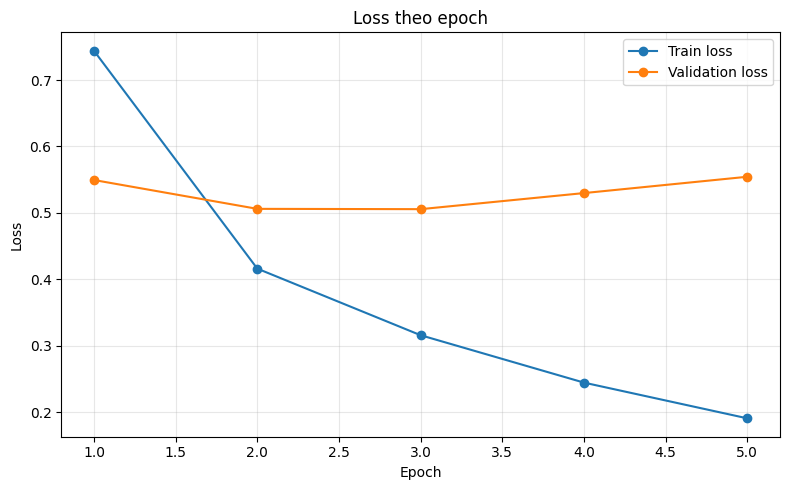

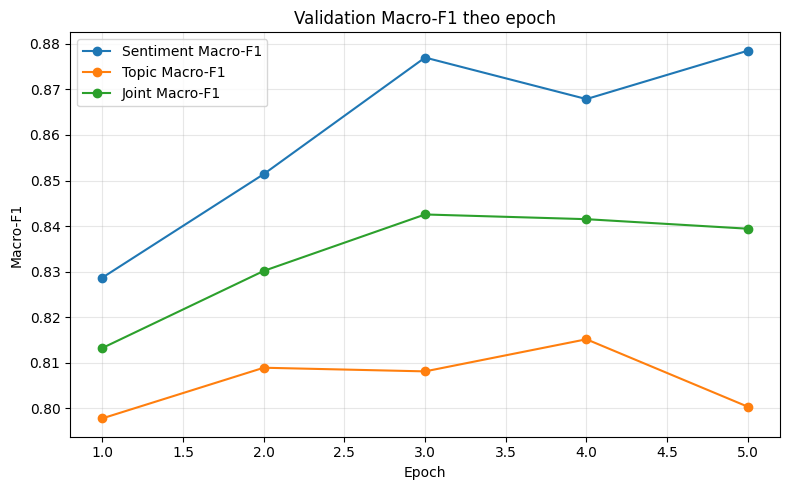

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation loss")
plt.title("Loss theo epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(
    history_df["epoch"],
    history_df["val_sentiment_macro_f1"],
    marker="o",
    label="Sentiment Macro-F1",
)
plt.plot(
    history_df["epoch"],
    history_df["val_topic_macro_f1"],
    marker="o",
    label="Topic Macro-F1",
)
plt.plot(
    history_df["epoch"],
    history_df["val_joint_macro_f1"],
    marker="o",
    label="Joint Macro-F1",
)
plt.title("Validation Macro-F1 theo epoch")
plt.xlabel("Epoch")
plt.ylabel("Macro-F1")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Tải checkpoint tốt nhất và đánh giá trên test

Test split chỉ được sử dụng **sau khi** hoàn tất lựa chọn mô hình trên validation split.

In [ ]:
checkpoint = torch.load(BEST_MODEL_PATH, map_location="cpu", weights_only=False)

best_model = PhoBERTMultiTask(
    checkpoint["model_name"],
    num_sentiment_labels=len(checkpoint["sentiment_names"]),
    num_topic_labels=len(checkpoint["topic_names"]),
    dropout=checkpoint["config"]["dropout"],
)
best_model.load_state_dict(checkpoint["model_state_dict"])
best_model.to(DEVICE)
best_model.eval()

sentiment_loss_fn = nn.CrossEntropyLoss(weight=sentiment_class_weights)
topic_loss_fn = nn.CrossEntropyLoss(weight=topic_class_weights)

test_result = evaluate_multitask(
    best_model,
    test_loader,
    sentiment_loss_fn,
    topic_loss_fn,
    return_probabilities=True,
)

print("===== TEST — SENTIMENT =====")
print_metrics(test_result["sentiment_metrics"])
print(
    classification_report(
        test_result["sentiment_true"],
        test_result["sentiment_pred"],
        labels=list(range(len(SENTIMENT_NAMES))),
        target_names=SENTIMENT_NAMES,
        digits=4,
        zero_division=0,
    )
)

print("===== TEST — TOPIC =====")
print_metrics(test_result["topic_metrics"])
print(
    classification_report(
        test_result["topic_true"],
        test_result["topic_pred"],
        labels=list(range(len(TOPIC_NAMES))),
        target_names=TOPIC_NAMES,
        digits=4,
        zero_division=0,
    )
)

print(f"Joint Macro-F1: {test_result['joint_macro_f1']:.4f}")

Some weights of RobertaModel were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Evaluate:   0%|          | 0/99 [00:00<?, ?it/s]

===== TEST — SENTIMENT =====
Accuracy=0.9375 | Macro-F1=0.8377 | Weighted-F1=0.9368
              precision    recall  f1-score   support

    negative     0.9538    0.9532    0.9535      1409
     neutral     0.6258    0.5808    0.6025       167
    positive     0.9532    0.9610    0.9571      1590

    accuracy                         0.9375      3166
   macro avg     0.8443    0.8317    0.8377      3166
weighted avg     0.9362    0.9375    0.9368      3166

===== TEST — TOPIC =====
Accuracy=0.8834 | Macro-F1=0.8023 | Weighted-F1=0.8874
                  precision    recall  f1-score   support

        lecturer     0.9480    0.9231    0.9354      2290
training_program     0.7774    0.7692    0.7733       572
        facility     0.9580    0.9448    0.9514       145
          others     0.4670    0.6667    0.5492       159

        accuracy                         0.8834      3166
       macro avg     0.7876    0.8260    0.8023      3166
    weighted avg     0.8935    0.8834    0.8874

## 13. Confusion matrix

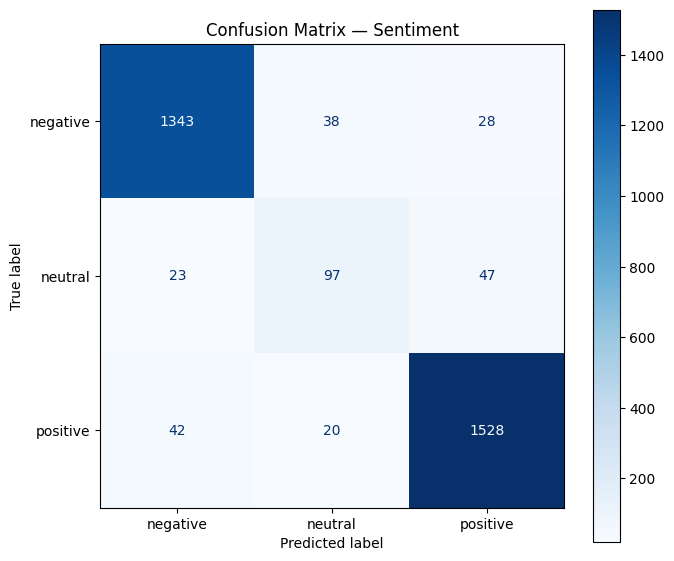

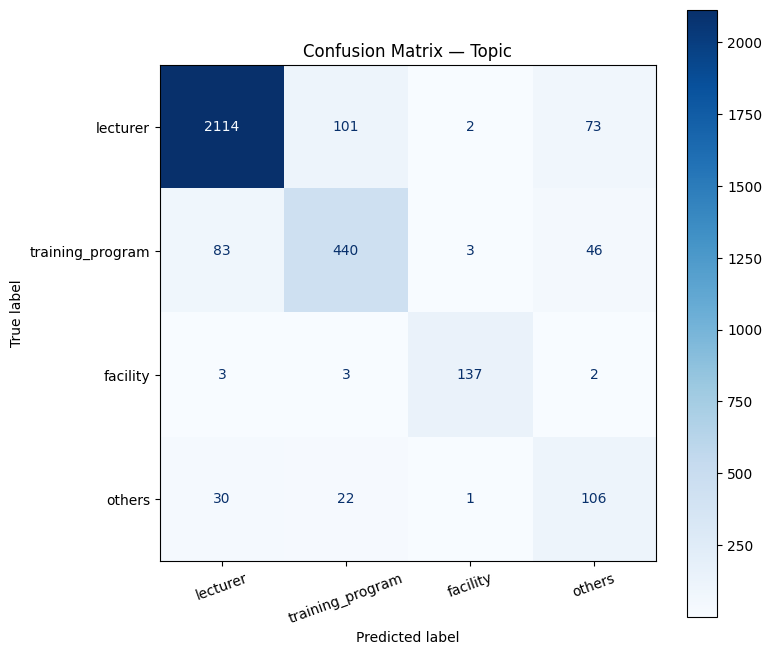

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    test_result["sentiment_true"],
    test_result["sentiment_pred"],
    labels=list(range(len(SENTIMENT_NAMES))),
    display_labels=SENTIMENT_NAMES,
    cmap="Blues",
    values_format="d",
    ax=ax,
)
plt.title("Confusion Matrix — Sentiment")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(
    test_result["topic_true"],
    test_result["topic_pred"],
    labels=list(range(len(TOPIC_NAMES))),
    display_labels=TOPIC_NAMES,
    cmap="Blues",
    values_format="d",
    ax=ax,
)
plt.title("Confusion Matrix — Topic")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 14. Mô hình LSTM đa nhiệm

LSTM được bổ sung như một mô hình học sâu tuần tự để so sánh trực tiếp với PhoBERT.

### Nguyên tắc so sánh công bằng

- Dùng **đúng cùng train/validation/test split** với PhoBERT.
- Vocabulary chỉ được xây dựng từ **train split** để tránh data leakage.
- Dùng cùng hai nhiệm vụ: sentiment (3 lớp) và topic (4 lớp).
- Dùng cùng class weight và cùng hàm loss đa nhiệm:
  \[
  L = 0.5L_{sentiment} + 0.5L_{topic}
  \]
- Chọn checkpoint tốt nhất theo **validation joint Macro-F1**.
- Test split chỉ được dùng sau khi hoàn tất chọn checkpoint.

Kiến trúc mặc định:

```text
Token IDs
   ↓
Embedding (128)
   ↓
LSTM (hidden=128)
   ↓
Dropout
   ├── Sentiment head → 3 lớp
   └── Topic head     → 4 lớp
```

> `LSTM_BIDIRECTIONAL=False` để đúng với mô hình LSTM thuần. Có thể đặt `True` nếu muốn thực hiện thêm thí nghiệm BiLSTM.


In [ ]:
from collections import Counter
from torch.nn.utils.rnn import pack_padded_sequence

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
PAD_ID = 0
UNK_ID = 1

def lstm_tokenize(text: str):
    """Tokenizer đơn giản cho LSTM: dùng kết quả tách từ đã có và tách theo khoảng trắng."""
    text = normalize_text(text)
    return text.split()

def build_lstm_vocab(texts, max_vocab_size=30000, min_freq=2):
    """Chỉ xây vocabulary từ train split để tránh data leakage."""
    counter = Counter()
    for text in tqdm(texts, desc="Xây vocabulary LSTM"):
        counter.update(lstm_tokenize(text))

    vocab = {
        PAD_TOKEN: PAD_ID,
        UNK_TOKEN: UNK_ID,
    }

    max_new_tokens = max(0, max_vocab_size - len(vocab))
    for token, freq in counter.most_common(max_new_tokens):
        if freq < min_freq:
            break
        if token not in vocab:
            vocab[token] = len(vocab)

    return vocab, counter

if RUN_LSTM:
    lstm_vocab, lstm_token_counter = build_lstm_vocab(
        train_df["segmented_text"],
        max_vocab_size=LSTM_MAX_VOCAB_SIZE,
        min_freq=LSTM_MIN_FREQ,
    )

    print(f"Kích thước vocabulary LSTM: {len(lstm_vocab):,}")
    print("10 token phổ biến:", lstm_token_counter.most_common(10))
else:
    lstm_vocab = {}
    lstm_token_counter = Counter()
    print("RUN_LSTM=False — bỏ qua xây vocabulary LSTM.")


Xây vocabulary LSTM:   0%|          | 0/11426 [00:00<?, ?it/s]

Kích thước vocabulary LSTM: 2,076
10 token phổ biến: [('.', 11008), (',', 6835), ('thầy', 3040), ('sinh_viên', 2698), ('dạy', 2163), ('và', 2068), ('không', 2031), ('rất', 1959), ('nhiệt_tình', 1848), ('cho', 1712)]


In [ ]:
class UITVSFCLSTMDataset(Dataset):
    def __init__(self, dataframe, vocab, max_length=128):
        self.df = dataframe.reset_index(drop=True)
        self.vocab = vocab
        self.max_length = max_length

    def __len__(self):
        return len(self.df)

    def encode(self, text):
        token_ids = [
            self.vocab.get(token, UNK_ID)
            for token in lstm_tokenize(text)
        ][: self.max_length]

        if not token_ids:
            token_ids = [UNK_ID]

        length = len(token_ids)
        if length < self.max_length:
            token_ids += [PAD_ID] * (self.max_length - length)

        return token_ids, length

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        token_ids, length = self.encode(row["segmented_text"])

        return {
            "input_ids": torch.tensor(token_ids, dtype=torch.long),
            "lengths": torch.tensor(length, dtype=torch.long),
            "sentiment_labels": torch.tensor(
                int(row["sentiment"]), dtype=torch.long
            ),
            "topic_labels": torch.tensor(
                int(row["topic"]), dtype=torch.long
            ),
            "row_id": torch.tensor(idx, dtype=torch.long),
        }

if RUN_LSTM:
    lstm_train_dataset = UITVSFCLSTMDataset(
        train_df, lstm_vocab, LSTM_MAX_LENGTH
    )
    lstm_val_dataset = UITVSFCLSTMDataset(
        val_df, lstm_vocab, LSTM_MAX_LENGTH
    )
    lstm_test_dataset = UITVSFCLSTMDataset(
        test_df, lstm_vocab, LSTM_MAX_LENGTH
    )

    lstm_train_loader = DataLoader(
        lstm_train_dataset,
        batch_size=LSTM_BATCH_SIZE,
        shuffle=True,
        num_workers=0,
        pin_memory=USE_AMP,
    )
    lstm_val_loader = DataLoader(
        lstm_val_dataset,
        batch_size=LSTM_EVAL_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=USE_AMP,
    )
    lstm_test_loader = DataLoader(
        lstm_test_dataset,
        batch_size=LSTM_EVAL_BATCH_SIZE,
        shuffle=False,
        num_workers=0,
        pin_memory=USE_AMP,
    )

    lstm_sample_batch = next(iter(lstm_train_loader))
    print({
        key: tuple(value.shape)
        for key, value in lstm_sample_batch.items()
    })


{'input_ids': (64, 128), 'lengths': (64,), 'sentiment_labels': (64,), 'topic_labels': (64,), 'row_id': (64,)}


In [ ]:
class LSTMMultiTask(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim=128,
        hidden_size=128,
        num_layers=1,
        num_sentiment_labels=3,
        num_topic_labels=4,
        dropout=0.3,
        bidirectional=False,
        padding_idx=PAD_ID,
    ):
        super().__init__()

        self.bidirectional = bidirectional
        self.num_layers = num_layers

        self.embedding = nn.Embedding(
            vocab_size,
            embedding_dim,
            padding_idx=padding_idx,
        )

        # dropout trong nn.LSTM chỉ có tác dụng khi num_layers > 1.
        recurrent_dropout = dropout if num_layers > 1 else 0.0

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=recurrent_dropout,
            bidirectional=bidirectional,
        )

        representation_size = hidden_size * (2 if bidirectional else 1)
        self.dropout = nn.Dropout(dropout)
        self.sentiment_classifier = nn.Linear(
            representation_size, num_sentiment_labels
        )
        self.topic_classifier = nn.Linear(
            representation_size, num_topic_labels
        )

    def forward(self, input_ids, lengths):
        embedded = self.embedding(input_ids)

        packed = pack_padded_sequence(
            embedded,
            lengths.detach().cpu(),
            batch_first=True,
            enforce_sorted=False,
        )

        _, (hidden, _) = self.lstm(packed)

        if self.bidirectional:
            # Hai state cuối tương ứng forward/backward của layer cuối.
            representation = torch.cat(
                (hidden[-2], hidden[-1]),
                dim=1,
            )
        else:
            representation = hidden[-1]

        representation = self.dropout(representation)

        sentiment_logits = self.sentiment_classifier(representation)
        topic_logits = self.topic_classifier(representation)
        return sentiment_logits, topic_logits


def move_lstm_batch_to_device(batch, device):
    return {
        key: value.to(device, non_blocking=True)
        for key, value in batch.items()
        if key != "row_id"
    }


@torch.no_grad()
def evaluate_lstm_multitask(
    model,
    data_loader,
    sentiment_loss_fn,
    topic_loss_fn,
    return_probabilities=False,
):
    model.eval()

    losses = []
    sentiment_losses = []
    topic_losses = []

    all_sentiment_true = []
    all_sentiment_pred = []
    all_sentiment_prob = []

    all_topic_true = []
    all_topic_pred = []
    all_topic_prob = []

    all_row_ids = []

    for batch in tqdm(data_loader, desc="Evaluate LSTM", leave=False):
        row_ids = batch["row_id"].numpy().tolist()
        batch = move_lstm_batch_to_device(batch, DEVICE)

        sentiment_logits, topic_logits = model(
            input_ids=batch["input_ids"],
            lengths=batch["lengths"],
        )

        total_loss, sentiment_loss, topic_loss = calculate_multitask_loss(
            sentiment_logits,
            topic_logits,
            batch["sentiment_labels"],
            batch["topic_labels"],
            sentiment_loss_fn,
            topic_loss_fn,
            LAMBDA_SENTIMENT,
            LAMBDA_TOPIC,
        )

        sentiment_prob = torch.softmax(sentiment_logits, dim=-1)
        topic_prob = torch.softmax(topic_logits, dim=-1)

        losses.append(total_loss.item())
        sentiment_losses.append(sentiment_loss.item())
        topic_losses.append(topic_loss.item())

        all_sentiment_true.extend(batch["sentiment_labels"].cpu().numpy())
        all_sentiment_pred.extend(sentiment_prob.argmax(dim=-1).cpu().numpy())
        all_sentiment_prob.extend(sentiment_prob.cpu().numpy())

        all_topic_true.extend(batch["topic_labels"].cpu().numpy())
        all_topic_pred.extend(topic_prob.argmax(dim=-1).cpu().numpy())
        all_topic_prob.extend(topic_prob.cpu().numpy())

        all_row_ids.extend(row_ids)

    sentiment_metrics = metric_dict(
        all_sentiment_true, all_sentiment_pred
    )
    topic_metrics = metric_dict(
        all_topic_true, all_topic_pred
    )

    result = {
        "loss": float(np.mean(losses)),
        "sentiment_loss": float(np.mean(sentiment_losses)),
        "topic_loss": float(np.mean(topic_losses)),
        "sentiment_metrics": sentiment_metrics,
        "topic_metrics": topic_metrics,
        "joint_macro_f1": (
            sentiment_metrics["f1_macro"]
            + topic_metrics["f1_macro"]
        ) / 2,
        "sentiment_true": np.asarray(all_sentiment_true),
        "sentiment_pred": np.asarray(all_sentiment_pred),
        "topic_true": np.asarray(all_topic_true),
        "topic_pred": np.asarray(all_topic_pred),
        "row_ids": np.asarray(all_row_ids),
    }

    if return_probabilities:
        result["sentiment_prob"] = np.asarray(all_sentiment_prob)
        result["topic_prob"] = np.asarray(all_topic_prob)

    return result


def train_lstm_multitask_model(model, train_loader, val_loader):
    sentiment_loss_fn = nn.CrossEntropyLoss(
        weight=sentiment_class_weights
    )
    topic_loss_fn = nn.CrossEntropyLoss(
        weight=topic_class_weights
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LSTM_LEARNING_RATE,
        weight_decay=LSTM_WEIGHT_DECAY,
    )

    # Giảm learning rate nếu validation joint Macro-F1 chững lại.
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
    )

    history = []
    best_score = -np.inf
    epochs_without_improvement = 0

    for epoch in range(1, LSTM_EPOCHS + 1):
        model.train()

        running_total = []
        running_sentiment = []
        running_topic = []

        progress = tqdm(
            train_loader,
            desc=f"LSTM Epoch {epoch}/{LSTM_EPOCHS}",
        )

        for batch in progress:
            batch = move_lstm_batch_to_device(batch, DEVICE)
            optimizer.zero_grad(set_to_none=True)

            sentiment_logits, topic_logits = model(
                input_ids=batch["input_ids"],
                lengths=batch["lengths"],
            )

            total_loss, sentiment_loss, topic_loss = calculate_multitask_loss(
                sentiment_logits,
                topic_logits,
                batch["sentiment_labels"],
                batch["topic_labels"],
                sentiment_loss_fn,
                topic_loss_fn,
                LAMBDA_SENTIMENT,
                LAMBDA_TOPIC,
            )

            total_loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                LSTM_MAX_GRAD_NORM,
            )

            optimizer.step()

            running_total.append(total_loss.item())
            running_sentiment.append(sentiment_loss.item())
            running_topic.append(topic_loss.item())

            progress.set_postfix(
                loss=f"{np.mean(running_total[-30:]):.4f}",
                lr=f"{optimizer.param_groups[0]['lr']:.2e}",
            )

        val_result = evaluate_lstm_multitask(
            model,
            val_loader,
            sentiment_loss_fn,
            topic_loss_fn,
        )

        scheduler.step(val_result["joint_macro_f1"])

        epoch_row = {
            "epoch": epoch,
            "train_loss": float(np.mean(running_total)),
            "train_sentiment_loss": float(np.mean(running_sentiment)),
            "train_topic_loss": float(np.mean(running_topic)),
            "val_loss": val_result["loss"],
            "val_sentiment_macro_f1":
                val_result["sentiment_metrics"]["f1_macro"],
            "val_topic_macro_f1":
                val_result["topic_metrics"]["f1_macro"],
            "val_joint_macro_f1":
                val_result["joint_macro_f1"],
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
        history.append(epoch_row)

        print(
            f"\nLSTM Epoch {epoch}: "
            f"train_loss={epoch_row['train_loss']:.4f} | "
            f"val_loss={epoch_row['val_loss']:.4f} | "
            f"sentiment_macro_f1="
            f"{epoch_row['val_sentiment_macro_f1']:.4f} | "
            f"topic_macro_f1="
            f"{epoch_row['val_topic_macro_f1']:.4f} | "
            f"joint_macro_f1="
            f"{epoch_row['val_joint_macro_f1']:.4f}"
        )

        if val_result["joint_macro_f1"] > best_score:
            best_score = val_result["joint_macro_f1"]
            epochs_without_improvement = 0

            checkpoint = {
                "model_state_dict": {
                    key: value.detach().cpu()
                    for key, value in model.state_dict().items()
                },
                "vocab": lstm_vocab,
                "sentiment_names": SENTIMENT_NAMES,
                "topic_names": TOPIC_NAMES,
                "config": {
                    "embedding_dim": LSTM_EMBED_DIM,
                    "hidden_size": LSTM_HIDDEN_SIZE,
                    "num_layers": LSTM_NUM_LAYERS,
                    "dropout": LSTM_DROPOUT,
                    "bidirectional": LSTM_BIDIRECTIONAL,
                    "max_length": LSTM_MAX_LENGTH,
                    "lambda_sentiment": LAMBDA_SENTIMENT,
                    "lambda_topic": LAMBDA_TOPIC,
                },
                "best_val_joint_macro_f1": float(best_score),
            }

            torch.save(checkpoint, BEST_LSTM_MODEL_PATH)
            print(
                f"✓ Đã lưu checkpoint LSTM tốt nhất: "
                f"{BEST_LSTM_MODEL_PATH}"
            )
        else:
            epochs_without_improvement += 1
            print(
                "LSTM không cải thiện: "
                f"{epochs_without_improvement}/{LSTM_PATIENCE}"
            )

            if epochs_without_improvement >= LSTM_PATIENCE:
                print("Early stopping LSTM.")
                break

    history_df = pd.DataFrame(history)
    history_df.to_csv(
        OUTPUT_DIR / "lstm_training_history.csv",
        index=False,
    )
    return history_df


if RUN_LSTM:
    lstm_model = LSTMMultiTask(
        vocab_size=len(lstm_vocab),
        embedding_dim=LSTM_EMBED_DIM,
        hidden_size=LSTM_HIDDEN_SIZE,
        num_layers=LSTM_NUM_LAYERS,
        num_sentiment_labels=len(SENTIMENT_NAMES),
        num_topic_labels=len(TOPIC_NAMES),
        dropout=LSTM_DROPOUT,
        bidirectional=LSTM_BIDIRECTIONAL,
    ).to(DEVICE)

    lstm_total_params, lstm_trainable_params = count_parameters(lstm_model)
    print(f"Tổng tham số LSTM: {lstm_total_params:,}")
    print(f"Tham số trainable LSTM: {lstm_trainable_params:,}")

    lstm_history_df = train_lstm_multitask_model(
        lstm_model,
        lstm_train_loader,
        lstm_val_loader,
    )
    display(lstm_history_df)
else:
    lstm_model = None
    lstm_history_df = pd.DataFrame()


Tổng tham số LSTM: 398,727
Tham số trainable LSTM: 398,727


LSTM Epoch 1/20:   0%|          | 0/179 [00:00<?, ?it/s]

Evaluate LSTM:   0%|          | 0/13 [00:00<?, ?it/s]


LSTM Epoch 1: train_loss=0.9389 | val_loss=0.7609 | sentiment_macro_f1=0.6919 | topic_macro_f1=0.6350 | joint_macro_f1=0.6634
✓ Đã lưu checkpoint LSTM tốt nhất: /content/uit_vsfc_phobert_project/best_lstm_multitask_model.pt


LSTM Epoch 2/20:   0%|          | 0/179 [00:00<?, ?it/s]

...


LSTM Epoch 15: train_loss=0.0664 | val_loss=1.2999 | sentiment_macro_f1=0.7842 | topic_macro_f1=0.7283 | joint_macro_f1=0.7563
LSTM không cải thiện: 2/3


LSTM Epoch 16/20:   0%|          | 0/179 [00:00<?, ?it/s]

Evaluate LSTM:   0%|          | 0/13 [00:00<?, ?it/s]


LSTM Epoch 16: train_loss=0.0543 | val_loss=1.3142 | sentiment_macro_f1=0.7797 | topic_macro_f1=0.7257 | joint_macro_f1=0.7527
LSTM không cải thiện: 3/3
Early stopping LSTM.


,epoch,train_loss,train_sentiment_loss,train_topic_loss,val_loss,val_sentiment_macro_f1,val_topic_macro_f1,val_joint_macro_f1,learning_rate
0,1,0.938910,0.795020,1.082801,0.760867,0.691882,0.635007,0.663445,0.00100
1,2,0.606565,0.545791,0.667338,0.593779,0.699047,0.673726,0.686387,0.00100
2,3,0.499693,0.445831,0.553556,0.582911,0.701307,0.691007,0.696157,0.00100
3,4,0.419127,0.364890,0.473365,0.579288,0.722746,0.690339,0.706543,0.00100
4,5,0.345034,0.305626,0.384443,0.674102,0.741108,0.694735,0.717921,0.00100
5,6,0.285397,0.247398,0.323396,0.728690,0.747252,0.711728,0.729490,0.00100
6,7,0.240773,0.203896,0.277649,0.772732,0.763933,0.718351,0.741142,0.00100
7,8,0.198038,0.157534,0.238542,0.862388,0.772649,0.727381,0.750015,0.00100
8,9,0.169268,0.138636,0.199899,0.922120,0.754743,0.723605,0.739174,0.00100
9,10,0.143850,0.116591,0.171108,0.951417,0.762743,0.721402,0.742072,0.00050


## 15. Đường cong huấn luyện LSTM

Theo dõi đồng thời train/validation loss và Macro-F1 để xác định LSTM đã hội tụ hay bắt đầu overfitting.


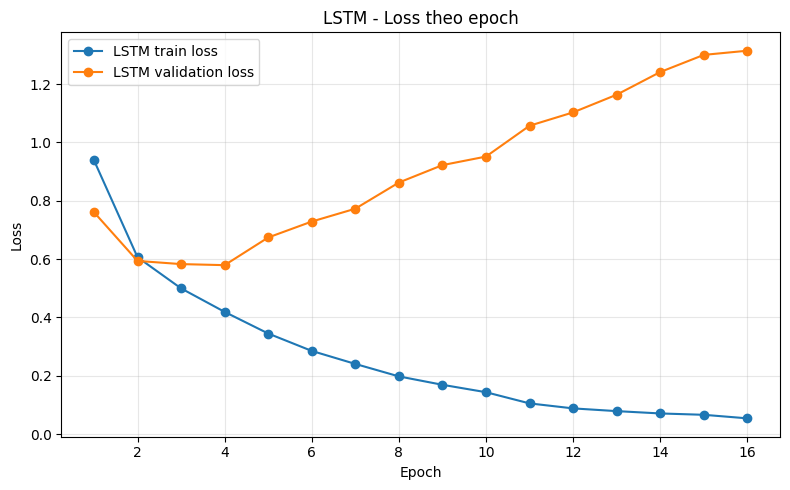

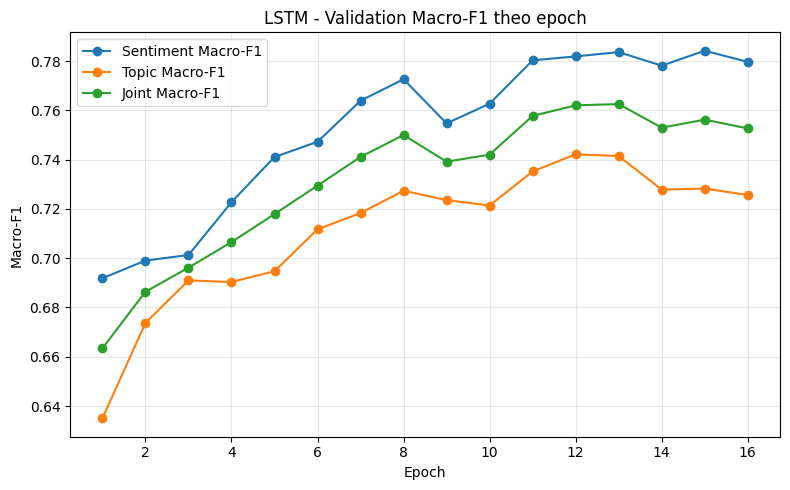

In [ ]:
if RUN_LSTM and not lstm_history_df.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(
        lstm_history_df["epoch"],
        lstm_history_df["train_loss"],
        marker="o",
        label="LSTM train loss",
    )
    plt.plot(
        lstm_history_df["epoch"],
        lstm_history_df["val_loss"],
        marker="o",
        label="LSTM validation loss",
    )
    plt.title("LSTM - Loss theo epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(
        lstm_history_df["epoch"],
        lstm_history_df["val_sentiment_macro_f1"],
        marker="o",
        label="Sentiment Macro-F1",
    )
    plt.plot(
        lstm_history_df["epoch"],
        lstm_history_df["val_topic_macro_f1"],
        marker="o",
        label="Topic Macro-F1",
    )
    plt.plot(
        lstm_history_df["epoch"],
        lstm_history_df["val_joint_macro_f1"],
        marker="o",
        label="Joint Macro-F1",
    )
    plt.title("LSTM - Validation Macro-F1 theo epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## 16. Tải checkpoint LSTM tốt nhất và đánh giá trên test

Tương tự PhoBERT, checkpoint LSTM được chọn hoàn toàn dựa trên validation split trước khi đánh giá trên test split.


In [ ]:
if RUN_LSTM:
    lstm_checkpoint = torch.load(
        BEST_LSTM_MODEL_PATH,
        map_location="cpu",
        weights_only=False,
    )

    best_lstm_model = LSTMMultiTask(
        vocab_size=len(lstm_checkpoint["vocab"]),
        embedding_dim=lstm_checkpoint["config"]["embedding_dim"],
        hidden_size=lstm_checkpoint["config"]["hidden_size"],
        num_layers=lstm_checkpoint["config"]["num_layers"],
        num_sentiment_labels=len(lstm_checkpoint["sentiment_names"]),
        num_topic_labels=len(lstm_checkpoint["topic_names"]),
        dropout=lstm_checkpoint["config"]["dropout"],
        bidirectional=lstm_checkpoint["config"]["bidirectional"],
    )

    best_lstm_model.load_state_dict(
        lstm_checkpoint["model_state_dict"]
    )
    best_lstm_model.to(DEVICE)
    best_lstm_model.eval()

    lstm_sentiment_loss_fn = nn.CrossEntropyLoss(
        weight=sentiment_class_weights
    )
    lstm_topic_loss_fn = nn.CrossEntropyLoss(
        weight=topic_class_weights
    )

    lstm_test_result = evaluate_lstm_multitask(
        best_lstm_model,
        lstm_test_loader,
        lstm_sentiment_loss_fn,
        lstm_topic_loss_fn,
        return_probabilities=True,
    )

    print("===== LSTM TEST — SENTIMENT =====")
    print_metrics(lstm_test_result["sentiment_metrics"])
    print(
        classification_report(
            lstm_test_result["sentiment_true"],
            lstm_test_result["sentiment_pred"],
            labels=list(range(len(SENTIMENT_NAMES))),
            target_names=SENTIMENT_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    print("===== LSTM TEST — TOPIC =====")
    print_metrics(lstm_test_result["topic_metrics"])
    print(
        classification_report(
            lstm_test_result["topic_true"],
            lstm_test_result["topic_pred"],
            labels=list(range(len(TOPIC_NAMES))),
            target_names=TOPIC_NAMES,
            digits=4,
            zero_division=0,
        )
    )

    print(
        "LSTM Joint Macro-F1: "
        f"{lstm_test_result['joint_macro_f1']:.4f}"
    )
else:
    best_lstm_model = None
    lstm_test_result = None


Evaluate LSTM:   0%|          | 0/25 [00:00<?, ?it/s]

===== LSTM TEST — SENTIMENT =====
Accuracy=0.8888 | Macro-F1=0.7509 | Weighted-F1=0.8889
              precision    recall  f1-score   support

    negative     0.9107    0.9042    0.9074      1409
     neutral     0.4226    0.4251    0.4239       167
    positive     0.9187    0.9239    0.9213      1590

    accuracy                         0.8888      3166
   macro avg     0.7507    0.7511    0.7509      3166
weighted avg     0.8889    0.8888    0.8889      3166

===== LSTM TEST — TOPIC =====
Accuracy=0.8389 | Macro-F1=0.7358 | Weighted-F1=0.8463
                  precision    recall  f1-score   support

        lecturer     0.9446    0.8716    0.9067      2290
training_program     0.6362    0.7920    0.7056       572
        facility     0.8865    0.8621    0.8741       145
          others     0.4100    0.5157    0.4568       159

        accuracy                         0.8389      3166
       macro avg     0.7193    0.7603    0.7358      3166
    weighted avg     0.8594    0.8389

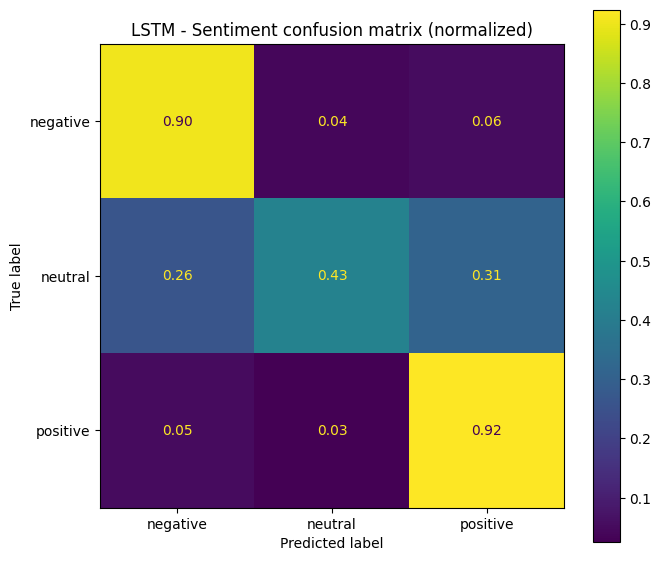

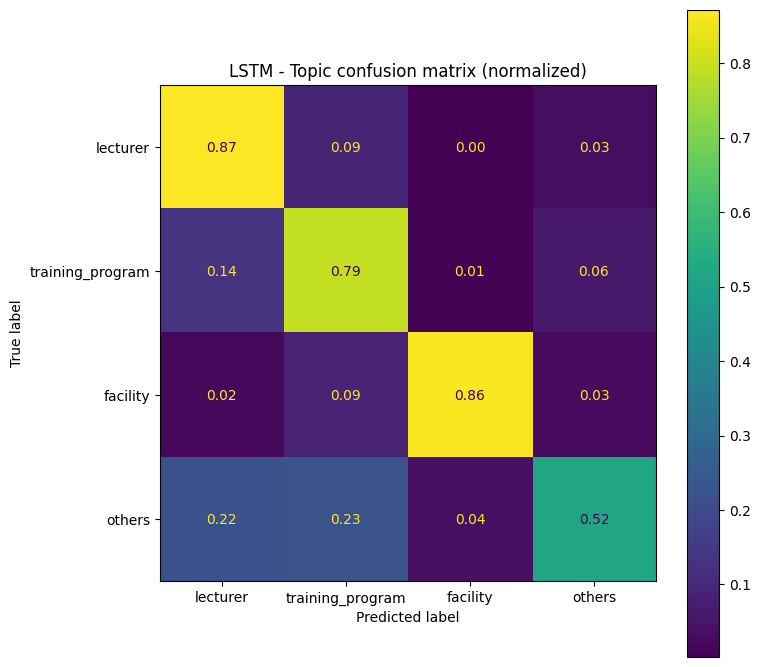

In [ ]:
if RUN_LSTM and lstm_test_result is not None:
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        lstm_test_result["sentiment_true"],
        lstm_test_result["sentiment_pred"],
        labels=list(range(len(SENTIMENT_NAMES))),
        display_labels=SENTIMENT_NAMES,
        normalize="true",
        values_format=".2f",
        ax=ax,
    )
    ax.set_title("LSTM - Sentiment confusion matrix (normalized)")
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(
        lstm_test_result["topic_true"],
        lstm_test_result["topic_pred"],
        labels=list(range(len(TOPIC_NAMES))),
        display_labels=TOPIC_NAMES,
        normalize="true",
        values_format=".2f",
        ax=ax,
    )
    ax.set_title("LSTM - Topic confusion matrix (normalized)")
    plt.tight_layout()
    plt.show()


## 17. Bảng so sánh trực tiếp PhoBERT và LSTM

Đây là bảng chính dùng trong phần thực nghiệm của báo cáo. Hai mô hình được đánh giá trên **cùng test split**.

- `Sentiment Macro-F1`: cân bằng chất lượng giữa 3 lớp cảm xúc.
- `Topic Macro-F1`: cân bằng chất lượng giữa 4 lớp chủ đề.
- `Joint Macro-F1`: trung bình Macro-F1 của hai nhiệm vụ, dùng làm chỉ số tổng hợp.
- Bảng chi tiết phía dưới vẫn giữ Accuracy, Precision, Recall, Macro-F1 và Weighted-F1 cho từng task.


===== SO SÁNH TỔNG HỢP PHOBERT VS LSTM =====


,model,sentiment_accuracy,sentiment_macro_f1,topic_accuracy,topic_macro_f1,joint_macro_f1
0,PhoBERT Multi-task,0.9375,0.8377,0.8834,0.8023,0.8200
1,LSTM Multi-task,0.8888,0.7509,0.8389,0.7358,0.7433


===== CHI TIẾT THEO TASK =====


,model,task,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,PhoBERT Multi-task,sentiment,0.9375,0.8443,0.8317,0.8377,0.9368
2,LSTM Multi-task,sentiment,0.8888,0.7507,0.7511,0.7509,0.8889
1,PhoBERT Multi-task,topic,0.8834,0.7876,0.8260,0.8023,0.8874
3,LSTM Multi-task,topic,0.8389,0.7193,0.7603,0.7358,0.8463


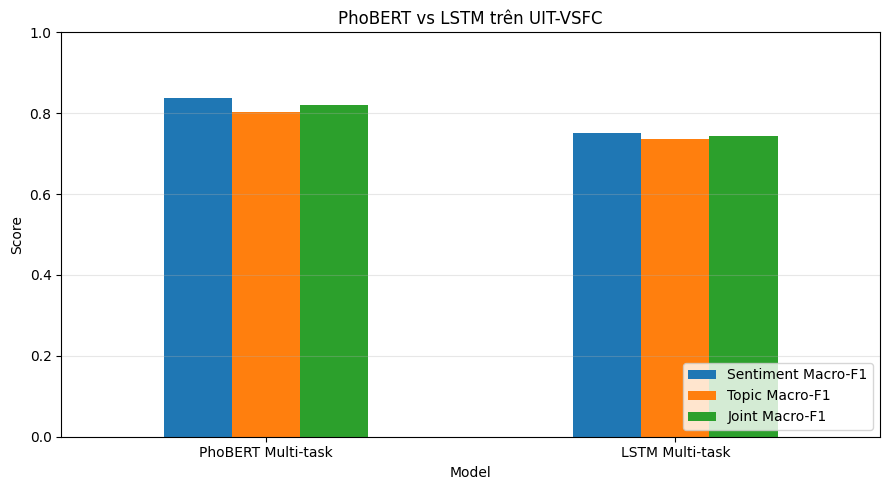

===== BẢNG MỞ RỘNG (CÓ BASELINE NẾU RUN_BASELINE=True) =====


,model,task,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,PhoBERT Multi-task,sentiment,0.9375,0.8443,0.8317,0.8377,0.9368
2,LSTM Multi-task,sentiment,0.8888,0.7507,0.7511,0.7509,0.8889
4,TF-IDF + Logistic Regression,sentiment,0.8740,0.7282,0.7699,0.7428,0.8807
1,PhoBERT Multi-task,topic,0.8834,0.7876,0.8260,0.8023,0.8874
3,LSTM Multi-task,topic,0.8389,0.7193,0.7603,0.7358,0.8463
5,TF-IDF + Logistic Regression,topic,0.8102,0.6920,0.7870,0.7243,0.8259


In [ ]:
two_model_summary_rows = [
    {
        "model": "PhoBERT Multi-task",
        "sentiment_accuracy":
            test_result["sentiment_metrics"]["accuracy"],
        "sentiment_macro_f1":
            test_result["sentiment_metrics"]["f1_macro"],
        "topic_accuracy":
            test_result["topic_metrics"]["accuracy"],
        "topic_macro_f1":
            test_result["topic_metrics"]["f1_macro"],
        "joint_macro_f1":
            test_result["joint_macro_f1"],
    }
]

if RUN_LSTM and lstm_test_result is not None:
    two_model_summary_rows.append(
        {
            "model": "LSTM Multi-task",
            "sentiment_accuracy":
                lstm_test_result["sentiment_metrics"]["accuracy"],
            "sentiment_macro_f1":
                lstm_test_result["sentiment_metrics"]["f1_macro"],
            "topic_accuracy":
                lstm_test_result["topic_metrics"]["accuracy"],
            "topic_macro_f1":
                lstm_test_result["topic_metrics"]["f1_macro"],
            "joint_macro_f1":
                lstm_test_result["joint_macro_f1"],
        }
    )

two_model_summary_df = pd.DataFrame(two_model_summary_rows)
two_model_summary_df = two_model_summary_df.sort_values(
    "joint_macro_f1",
    ascending=False,
).reset_index(drop=True)

print("===== SO SÁNH TỔNG HỢP PHOBERT VS LSTM =====")
display(two_model_summary_df.round(4))

two_model_summary_df.to_csv(
    OUTPUT_DIR / "phobert_vs_lstm_summary.csv",
    index=False,
)

# Bảng chi tiết theo từng task.
comparison_rows = [
    {
        "model": "PhoBERT Multi-task",
        "task": "sentiment",
        **test_result["sentiment_metrics"],
    },
    {
        "model": "PhoBERT Multi-task",
        "task": "topic",
        **test_result["topic_metrics"],
    },
]

if RUN_LSTM and lstm_test_result is not None:
    comparison_rows.extend([
        {
            "model": "LSTM Multi-task",
            "task": "sentiment",
            **lstm_test_result["sentiment_metrics"],
        },
        {
            "model": "LSTM Multi-task",
            "task": "topic",
            **lstm_test_result["topic_metrics"],
        },
    ])

comparison_df = pd.DataFrame(comparison_rows)
comparison_df = comparison_df[
    [
        "model",
        "task",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "f1_weighted",
    ]
].sort_values(
    ["task", "f1_macro"],
    ascending=[True, False],
)

print("===== CHI TIẾT THEO TASK =====")
display(comparison_df.round(4))

comparison_df.to_csv(
    OUTPUT_DIR / "phobert_vs_lstm_detailed.csv",
    index=False,
)

# Biểu đồ Macro-F1 trực quan.
plot_df = two_model_summary_df.set_index("model")[
    [
        "sentiment_macro_f1",
        "topic_macro_f1",
        "joint_macro_f1",
    ]
].rename(
    columns={
        "sentiment_macro_f1": "Sentiment Macro-F1",
        "topic_macro_f1": "Topic Macro-F1",
        "joint_macro_f1": "Joint Macro-F1",
    }
)

ax = plot_df.plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0, 1),
    rot=0,
)
ax.set_title("PhoBERT vs LSTM trên UIT-VSFC")
ax.set_ylabel("Score")
ax.set_xlabel("Model")
ax.legend(loc="lower right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Bảng mở rộng: thêm baseline truyền thống nếu đã chạy.
extended_rows = comparison_rows.copy()

if RUN_BASELINE and baseline_results:
    extended_rows.extend([
        {
            "model": "TF-IDF + Logistic Regression",
            "task": "sentiment",
            **baseline_results["sentiment_test"],
        },
        {
            "model": "TF-IDF + Logistic Regression",
            "task": "topic",
            **baseline_results["topic_test"],
        },
    ])

extended_comparison_df = pd.DataFrame(extended_rows)
extended_comparison_df = extended_comparison_df[
    [
        "model",
        "task",
        "accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "f1_weighted",
    ]
].sort_values(
    ["task", "f1_macro"],
    ascending=[True, False],
)

print("===== BẢNG MỞ RỘNG (CÓ BASELINE NẾU RUN_BASELINE=True) =====")
display(extended_comparison_df.round(4))
extended_comparison_df.to_csv(
    OUTPUT_DIR / "model_comparison_extended.csv",
    index=False,
)


## 18. Phân tích lỗi

Phần này tạo bảng chứa:

- Câu gốc.
- Nhãn thật và nhãn dự đoán.
- Độ tin cậy.
- Cờ dự đoán sai cho từng nhiệm vụ.

Nên đọc thủ công 50–100 trường hợp sai và nhóm lỗi thành:

1. Câu có nhiều chủ đề.
2. Câu có cảm xúc trái chiều.
3. Phủ định phức tạp.
4. Câu quá ngắn hoặc thiếu ngữ cảnh.
5. Lỗi chính tả/từ viết tắt.
6. Nhãn gốc có tính mơ hồ.

In [ ]:
# Xây dựng bảng phân tích lỗi từ kết quả trên test split
# row_ids cho biết thứ tự các dòng của test_df tương ứng với dự đoán.
test_eval_df = test_df.reset_index(drop=True)
row_ids = test_result["row_ids"].astype(int)

error_df = pd.DataFrame(
    {
        "sentence": test_eval_df.loc[row_ids, "sentence"].to_numpy(),
        "segmented_text": test_eval_df.loc[row_ids, "segmented_text"].to_numpy(),
        "true_sentiment": [ID_TO_SENTIMENT[int(i)] for i in test_result["sentiment_true"]],
        "pred_sentiment": [ID_TO_SENTIMENT[int(i)] for i in test_result["sentiment_pred"]],
        "sentiment_confidence": test_result["sentiment_prob"].max(axis=1),
        "true_topic": [ID_TO_TOPIC[int(i)] for i in test_result["topic_true"]],
        "pred_topic": [ID_TO_TOPIC[int(i)] for i in test_result["topic_pred"]],
        "topic_confidence": test_result["topic_prob"].max(axis=1),
    }
)

error_df["sentiment_error"] = error_df["true_sentiment"] != error_df["pred_sentiment"]
error_df["topic_error"] = error_df["true_topic"] != error_df["pred_topic"]
error_df["any_error"] = error_df["sentiment_error"] | error_df["topic_error"]

# Chuyển float16 sang float32 để Pandas có thể sắp xếp
error_df["sentiment_confidence"] = (
    error_df["sentiment_confidence"].astype(np.float32)
)

error_df["topic_confidence"] = (
    error_df["topic_confidence"].astype(np.float32)
)

error_df.to_csv(OUTPUT_DIR / "test_predictions_and_errors.csv", index=False)

print("Số lỗi sentiment:", int(error_df["sentiment_error"].sum()))
print("Số lỗi topic:", int(error_df["topic_error"].sum()))
print(
    "Số câu sai ít nhất một nhiệm vụ:",
    int(error_df["any_error"].sum()),
)

display(
    error_df.loc[
        error_df["any_error"],
        [
            "sentence",
            "true_sentiment",
            "pred_sentiment",
            "sentiment_confidence",
            "true_topic",
            "pred_topic",
            "topic_confidence",
        ],
    ]
    .sort_values(
        by=["sentiment_confidence", "topic_confidence"],
        ascending=[False, False],
    )
    .head(30)
)

Số lỗi sentiment: 198
Số lỗi topic: 369
Số câu sai ít nhất một nhiệm vụ: 512


,sentence,true_sentiment,pred_sentiment,sentiment_confidence,true_topic,pred_topic,topic_confidence
430,"thời gian hợp lý , thái độ thoải mái .",positive,positive,0.991699,training_program,lecturer,0.812988
983,hoặc nếu thấy bất tiện thì trường em nghĩ trườ...,negative,negative,0.991699,training_program,facility,0.426025
306,"cần thêm các đội ngũ giảng viên trình độ pgs ,...",negative,negative,0.991211,training_program,lecturer,0.499268
1520,"cung cấp nhiều kiến thức mới , bổ ích .",positive,positive,0.990723,training_program,lecturer,0.835938
767,"nhiều buổi học không có giảng viên , khi liên ...",negative,negative,0.990723,training_program,lecturer,0.550781
147,"ít có thời gian thực hành bằng thiết bị thật ,...",negative,negative,0.990234,facility,training_program,0.854492
2334,em chỉ dám thỉnh cầu quý thầy cô soạn ra một b...,negative,negative,0.990234,lecturer,training_program,0.726074
1257,"thời gian được sử dụng tốt , hoạt động liên tụ...",positive,positive,0.990234,lecturer,training_program,0.415039
2965,cô rất tận tình trong việc củng cố kiến thức .,positive,positive,0.989746,training_program,lecturer,0.912598
2760,kiến thức hay và sự tận tâm của giảng viên .,positive,positive,0.989746,training_program,lecturer,0.807129


In [ ]:
# Các lỗi có độ tin cậy cao thường đáng phân tích nhất.
high_confidence_errors = error_df[
    error_df["any_error"]
    & (
        (error_df["sentiment_confidence"] >= 0.80)
        | (error_df["topic_confidence"] >= 0.80)
    )
].copy()

display(
    high_confidence_errors[
        [
            "sentence",
            "true_sentiment",
            "pred_sentiment",
            "sentiment_confidence",
            "true_topic",
            "pred_topic",
            "topic_confidence",
        ]
    ].head(20)
)

,sentence,true_sentiment,pred_sentiment,sentiment_confidence,true_topic,pred_topic,topic_confidence
6,tính điểm thi đua các nhóm .,positive,neutral,0.984375,training_program,others,0.422852
12,trong trường macbook thầy số hai thì không có ...,positive,negative,0.934570,others,facility,0.978516
13,sinh viên không tiếp thu kịp cũng như không hi...,negative,negative,0.980469,training_program,others,0.496826
18,"còn những phần tìm bao đóng , chứng minh dạng ...",negative,negative,0.980469,training_program,others,0.461670
23,nên đưa ra một vài phương pháp học lập trình h...,negative,negative,0.986816,lecturer,training_program,0.810059
34,giữa lý thuyết từ vựng với trò chơi để dễ tiếp...,negative,positive,0.748535,training_program,training_program,0.936523
35,môn học này giúp chúng em hiểu ra những vấn đề...,neutral,positive,0.803223,training_program,training_program,0.958496
43,"cô vui tính , học không áp lực .",positive,positive,0.987793,training_program,lecturer,0.930664
45,phần lớn chỉ là lý thuyết và bài tập .,positive,negative,0.954102,training_program,training_program,0.944336
48,"cô nhiệt tình , giảng bài hiệu quả .",positive,positive,0.988770,training_program,lecturer,0.932129


## 19. Hàm dự đoán phản hồi mới

In [ ]:
@torch.no_grad()
def predict_feedback(text: str, model=best_model):
    if not isinstance(text, str) or not text.strip():
        raise ValueError("Văn bản đầu vào không được để trống.")

    normalized = normalize_text(text)
    segmented = word_segment_text(normalized)

    encoded = tokenizer(
        segmented,
        max_length=MAX_LENGTH,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    encoded = {key: value.to(DEVICE) for key, value in encoded.items()}

    model.eval()
    sentiment_logits, topic_logits = model(
        input_ids=encoded["input_ids"],
        attention_mask=encoded["attention_mask"],
        token_type_ids=encoded.get("token_type_ids"),
    )

    sentiment_probs = torch.softmax(sentiment_logits, dim=-1)[0].cpu().numpy()
    topic_probs = torch.softmax(topic_logits, dim=-1)[0].cpu().numpy()

    sentiment_id = int(sentiment_probs.argmax())
    topic_id = int(topic_probs.argmax())

    return {
        "text": normalized,
        "segmented_text": segmented,
        "sentiment": ID_TO_SENTIMENT[sentiment_id],
        "sentiment_confidence": float(sentiment_probs[sentiment_id]),
        "sentiment_probabilities": {
            name: float(prob)
            for name, prob in zip(SENTIMENT_NAMES, sentiment_probs)
        },
        "topic": ID_TO_TOPIC[topic_id],
        "topic_confidence": float(topic_probs[topic_id]),
        "topic_probabilities": {
            name: float(prob)
            for name, prob in zip(TOPIC_NAMES, topic_probs)
        },
    }

examples = [
    "Giảng viên giảng bài rất dễ hiểu và luôn hỗ trợ sinh viên.",
    "Phòng máy quá nóng, wifi yếu và máy tính thường xuyên bị lỗi.",
    "Nội dung môn học cần cập nhật thêm kiến thức thực tế.",
    "Môn học bình thường, em chưa có nhận xét gì thêm.",
]

for text in examples:
    result = predict_feedback(text)
    print("=" * 80)
    print("Văn bản:", result["text"])
    print(
        f"Sentiment: {result['sentiment']} "
        f"({result['sentiment_confidence']:.2%})"
    )
    print(
        f"Topic: {result['topic']} "
        f"({result['topic_confidence']:.2%})"
    )

Văn bản: Giảng viên giảng bài rất dễ hiểu và luôn hỗ trợ sinh viên.
Sentiment: positive (98.13%)
Topic: lecturer (96.40%)
Văn bản: Phòng máy quá nóng, wifi yếu và máy tính thường xuyên bị lỗi.
Sentiment: negative (93.92%)
Topic: facility (97.93%)
Văn bản: Nội dung môn học cần cập nhật thêm kiến thức thực tế.
Sentiment: negative (96.37%)
Topic: training_program (96.67%)
Văn bản: Môn học bình thường, em chưa có nhận xét gì thêm.
Sentiment: neutral (91.26%)
Topic: training_program (72.72%)


In [ ]:
import gradio as gr

def gradio_predict(text):
    try:
        result = predict_feedback(text)
        sentiment_scores = result["sentiment_probabilities"]
        topic_scores = result["topic_probabilities"]
        summary = (
            f"**Cảm xúc:** {result['sentiment']} "
            f"({result['sentiment_confidence']:.2%})\n\n"
            f"**Chủ đề:** {result['topic']} "
            f"({result['topic_confidence']:.2%})\n\n"
            f"**Văn bản sau tách từ:** `{result['segmented_text']}`"
        )
        return summary, sentiment_scores, topic_scores
    except Exception as exc:
        return f"Lỗi: {exc}", {}, {}

demo = gr.Interface(
    fn=gradio_predict,
    inputs=gr.Textbox(
        lines=5,
        label="Phản hồi sinh viên",
        placeholder="Nhập phản hồi tiếng Việt...",
    ),
    outputs=[
        gr.Markdown(label="Kết quả"),
        gr.Label(num_top_classes=3, label="Xác suất cảm xúc"),
        gr.Label(num_top_classes=4, label="Xác suất chủ đề"),
    ],
    title="PhoBERT đa nhiệm — Phân tích phản hồi sinh viên",
    description=(
        "Hệ thống đồng thời dự đoán cảm xúc và chủ đề "
        "trong phản hồi sinh viên tiếng Việt."
    ),
    examples=[[text] for text in examples],
)

demo.launch(debug=False, share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://6804a2f9dedcff69f7.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 20. Lưu mô hình, tokenizer và kết quả

File ZIP chứa:

- Trọng số PhoBERT đa nhiệm.
- Tokenizer PhoBERT.
- Checkpoint LSTM đa nhiệm (bao gồm vocabulary và cấu hình).
- Cấu hình nhãn.
- Lịch sử huấn luyện PhoBERT và LSTM.
- Bảng so sánh trực tiếp PhoBERT vs LSTM.
- Bảng so sánh mở rộng với baseline (nếu bật).
- Dự đoán và lỗi PhoBERT trên test.


In [ ]:
EXPORT_DIR = OUTPUT_DIR / "exported_model"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Lưu tokenizer PhoBERT
tokenizer.save_pretrained(EXPORT_DIR / "tokenizer")

# Lưu checkpoint PhoBERT
shutil.copy2(
    BEST_MODEL_PATH,
    EXPORT_DIR / BEST_MODEL_PATH.name,
)

# Lưu checkpoint LSTM nếu đã chạy
if RUN_LSTM and BEST_LSTM_MODEL_PATH.exists():
    shutil.copy2(
        BEST_LSTM_MODEL_PATH,
        EXPORT_DIR / BEST_LSTM_MODEL_PATH.name,
    )

metadata = {
    "dataset": DATASET_NAME,
    "base_model": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "sentiment_names": SENTIMENT_NAMES,
    "topic_names": TOPIC_NAMES,
    "phobert": {
        "test_sentiment_metrics": test_result["sentiment_metrics"],
        "test_topic_metrics": test_result["topic_metrics"],
        "test_joint_macro_f1": test_result["joint_macro_f1"],
    },
}

if RUN_LSTM and lstm_test_result is not None:
    metadata["lstm"] = {
        "max_length": LSTM_MAX_LENGTH,
        "embedding_dim": LSTM_EMBED_DIM,
        "hidden_size": LSTM_HIDDEN_SIZE,
        "num_layers": LSTM_NUM_LAYERS,
        "bidirectional": LSTM_BIDIRECTIONAL,
        "test_sentiment_metrics":
            lstm_test_result["sentiment_metrics"],
        "test_topic_metrics":
            lstm_test_result["topic_metrics"],
        "test_joint_macro_f1":
            lstm_test_result["joint_macro_f1"],
    }

with open(
    EXPORT_DIR / "metadata.json",
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        metadata,
        file,
        ensure_ascii=False,
        indent=2,
    )

for filename in [
    "training_history.csv",
    "lstm_training_history.csv",
    "phobert_vs_lstm_summary.csv",
    "phobert_vs_lstm_detailed.csv",
    "model_comparison_extended.csv",
    "test_predictions_and_errors.csv",
]:
    source = OUTPUT_DIR / filename
    if source.exists():
        shutil.copy2(
            source,
            EXPORT_DIR / filename,
        )

zip_path = shutil.make_archive(
    str(OUTPUT_DIR / "phobert_lstm_multitask_uit_vsfc"),
    "zip",
    root_dir=EXPORT_DIR,
)
print("Đã tạo:", zip_path)

# Đặt DOWNLOAD_ZIP = True nếu muốn tải file ZIP về máy.
DOWNLOAD_ZIP = False

if DOWNLOAD_ZIP:
    try:
        from google.colab import files
        files.download(zip_path)
    except ImportError:
        print(
            "Không ở trong Colab; lấy file trực tiếp tại:",
            zip_path,
        )
else:
    print(
        "Bỏ qua bước tải về. File ZIP nằm tại:",
        zip_path,
    )


Đã tạo: /content/uit_vsfc_phobert_project/phobert_lstm_multitask_uit_vsfc.zip
Bỏ qua bước tải về. File ZIP nằm tại: /content/uit_vsfc_phobert_project/phobert_lstm_multitask_uit_vsfc.zip


# Checklist báo cáo đồ án

## Chương 1 — Giới thiệu

- Bối cảnh phản hồi sinh viên.
- Vấn đề phân tích thủ công.
- Mục tiêu phân loại cảm xúc và chủ đề.
- Câu hỏi nghiên cứu.
- Đóng góp của đồ án.

## Chương 2 — Cơ sở lý thuyết

- Text classification.
- RNN, LSTM và cơ chế ghi nhớ dài hạn.
- Transformer và self-attention.
- Pre-training và fine-tuning.
- PhoBERT.
- Multi-task learning.
- TF-IDF và Logistic Regression.
- Accuracy, Precision, Recall, Macro-F1 và confusion matrix.

## Chương 3 — Phương pháp

- Dataset và cách chia split.
- Phân bố nhãn.
- Tiền xử lý.
- Kiến trúc LSTM multi-task.
- Kiến trúc PhoBERT multi-task.
- Hàm loss.
- Siêu tham số.
- Early stopping và class weight.

## Chương 4 — Thực nghiệm

- Môi trường phần cứng/phần mềm.
- Baseline.
- Kết quả PhoBERT.
- Kết quả LSTM.
- Bảng so sánh trực tiếp PhoBERT vs LSTM.
- Confusion matrix.
- Phân tích lỗi.

## Chương 5 — Kết luận

- Kết quả chính.
- Hạn chế.
- Hướng phát triển:
  - Dữ liệu đa nhãn.
  - Giải thích dự đoán.
  - Active learning.
  - Dashboard theo thời gian.
  - Triển khai API.

# Trích dẫn đề xuất

```bibtex
@inproceedings{nguyen2018uitvsfc,
  author    = {Kiet Van Nguyen and Vu Duc Nguyen and
               Phu X. V. Nguyen and Tham T. H. Truong and
               Ngan Luu-Thuy Nguyen},
  title     = {UIT-VSFC: Vietnamese Students' Feedback Corpus
               for Sentiment Analysis},
  booktitle = {2018 10th International Conference on
               Knowledge and Systems Engineering},
  year      = {2018},
  pages     = {19--24},
  doi       = {10.1109/KSE.2018.8573337}
}

@inproceedings{nguyen2020phobert,
  title     = {PhoBERT: Pre-trained language models for Vietnamese},
  author    = {Dat Quoc Nguyen and Anh Tuan Nguyen},
  booktitle = {Findings of the Association for Computational
               Linguistics: EMNLP 2020},
  year      = {2020}
}
```